<a href="https://colab.research.google.com/github/ozlemalci/AirDefenseSystemWithRL/blob/master/rl_airdefense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd


file_path = "DATASET.xlsx" # Excel dosyasını oku


df_aircraft = pd.read_excel(file_path, sheet_name="Aircraft") # Aircraft sayfasını yükle

print("Original columns after reading Excel:")
print(df_aircraft.columns)

# Sütun isimlerini sadeleştir
df_aircraft = df_aircraft.rename(columns={
    "Max Speed (km/h)": "MaxSpeed",
    "Max Range (km)": "MaxRange",
    "Max Altitude (m)": "MaxAltitude",
    "RCS (m²)": "RCS",
    "Cost (USD)" : "TargetCost"
})

print("Columns after renaming:")
print(df_aircraft.columns)

# Kullanılacak sütunları seç
df_aircraft = df_aircraft[
    ["Name", "MaxSpeed", "MaxRange", "MaxAltitude",
     "Maneuverability", "ECM", "RCS","Type", "TargetCost"]
].copy()

# Metin alanlarını temizle
text_cols = ["Name","Maneuverability", "ECM","Type"]
for col in text_cols:
    df_aircraft[col] = df_aircraft[col].astype(str).str.strip()


# Sayısal sütunları kontrol et
num_cols = ["MaxSpeed", "MaxRange", "MaxAltitude", "RCS", "TargetCost"]
for col in num_cols:
    df_aircraft[col] = pd.to_numeric(df_aircraft[col], errors="coerce")

# Eksik veri kontrolü
print("Eksik veri sayıları:")
print(df_aircraft.isnull().sum())


print(df_aircraft.head(30))

print("\nVeri seti boyutu:", df_aircraft.shape)

Original columns after reading Excel:
Index(['Name', 'Max Speed (km/h)', 'Max Range (km)', 'Max Altitude (m)',
       'Maneuverability', 'ECM', 'RCS (m²)', 'Type', 'Cost (USD)'],
      dtype='object')
Columns after renaming:
Index(['Name', 'MaxSpeed', 'MaxRange', 'MaxAltitude', 'Maneuverability', 'ECM',
       'RCS', 'Type', 'TargetCost'],
      dtype='object')
Eksik veri sayıları:
Name               0
MaxSpeed           0
MaxRange           0
MaxAltitude        0
Maneuverability    0
ECM                0
RCS                0
Type               0
TargetCost         0
dtype: int64
                     Name  MaxSpeed  MaxRange  MaxAltitude Maneuverability  \
0    F-16 Fighting Falcon      2180      4220        15240    AboveAverage   
1          F-4 Phantom II      2370      2816        18300            High   
2     Eurofighter Typhoon      2495      2900        19800         Extreme   
3         Dassault Rafale      1912      1850        15500         Extreme   
4           Su-27 Flank

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
import pandas as pd

# Önce mevcut dataframe'in kopyasını al
df_step2 = df_aircraft.copy()

#  Maneuverability için sayısal karşılıklar
maneuver_map = {

    "BelowAverage": 0.2,
    "Medium": 0.4,
    "AboveAverage": 0.6,
    "High": 0.8,
    "Extreme": 1.0
}

# ECM için sayısal karşılıklar
ecm_map = {
    "Decoy":0.2 ,
    "Advanced": 0.4,
    "Jammer": 0.6,
    "MultiMode": 0.8,
    "Stealth": 1.0
}

# Yeni sayısal sütunları oluştur

df_step2["ManeuverScore"] = df_step2["Maneuverability"].map(maneuver_map)
df_step2["ECMScore"] = df_step2["ECM"].map(ecm_map)

# Eşleşmeyen değer var mı kontrol et

print("Maneuverability eşleşmeyen değer sayısı:", df_step2["ManeuverScore"].isnull().sum())
print("ECM eşleşmeyen değer sayısı:", df_step2["ECMScore"].isnull().sum())

# Kontrol için ilgili sütunları göster
print("\nDönüştürülmüş ilk 15 satır:")
print(
    df_step2[
        ["Name","Maneuverability", "ManeuverScore", "ECM", "ECMScore"]
    ].head(15)
)

df_model = df_step2[
    ["Name", "MaxSpeed", "MaxRange", "MaxAltitude",
     "ManeuverScore", "ECMScore", "RCS", "TargetCost"]
].copy()

print("\nModel için kullanılacak tablo:")
print(df_model.head(30))

Maneuverability eşleşmeyen değer sayısı: 0
ECM eşleşmeyen değer sayısı: 0

Dönüştürülmüş ilk 15 satır:
                    Name Maneuverability  ManeuverScore        ECM  ECMScore
0   F-16 Fighting Falcon    AboveAverage            0.6  MultiMode       0.8
1         F-4 Phantom II            High            0.8   Advanced       0.4
2    Eurofighter Typhoon         Extreme            1.0    Stealth       1.0
3        Dassault Rafale         Extreme            1.0  MultiMode       0.8
4          Su-27 Flanker         Extreme            1.0    Stealth       1.0
5      F-35 Lightning II         Extreme            1.0    Stealth       1.0
6                   J-20    AboveAverage            0.6  MultiMode       0.8
7    B-52 Stratofortress    BelowAverage            0.2   Advanced       0.4
8             B-2 Spirit          Medium            0.4  MultiMode       0.8
9       Tu-160 Blackjack          Medium            0.4  MultiMode       0.8
10                   H-6    AboveAverage          

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
import pandas as pd
import numpy as np

# Modelde kullanılacak sütunlar
df_model = df_step2[
    ["Name", "MaxSpeed", "MaxRange", "MaxAltitude",
     "ManeuverScore", "ECMScore", "RCS", "TargetCost"]
].copy()

# Normalizasyon için kopya oluştur
df_norm = df_model.copy()

# Min-Max normalizasyon fonksiyonu
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# ThreatScore hesaplamasında kullanılacak değişkenler
cols_to_normalize = [
    "MaxSpeed",
    "MaxRange",
    "MaxAltitude",
    "ManeuverScore",
    "ECMScore"
]

for col in cols_to_normalize:
    df_norm[col] = min_max_normalize(df_norm[col])

# Hedef maliyetini (Target Cost) ayrı normalize et
df_norm["TargetCostScore"] = min_max_normalize(df_norm["TargetCost"])

# RCS işlemleri
# Log dönüşümü (dağılımı dengelemek için)
df_norm["RCS_log"] = np.log1p(df_norm["RCS"])

# Normalize et
df_norm["RCS_log"] = min_max_normalize(df_norm["RCS_log"])

# Ters çevir (küçük RCS = daha yüksek tehdit)
df_norm["RCS"] = 1 - df_norm["RCS_log"]

# Geçici sütunu kaldır
df_norm.drop(columns=["RCS_log"], inplace=True)

# Ham maliyet sütununu kaldır
df_norm.drop(columns=["TargetCost"], inplace=True)

print(df_norm.head(30))

                     Name  MaxSpeed  MaxRange  MaxAltitude  ManeuverScore  \
0    F-16 Fighting Falcon  0.855986  0.286131     0.735556           0.50   
1          F-4 Phantom II  0.941494  0.183650     0.905556           0.75   
2     Eurofighter Typhoon  0.997750  0.189781     0.988889           1.00   
3         Dassault Rafale  0.735374  0.113139     0.750000           1.00   
4           Su-27 Flanker  1.000000  0.235766     0.944444           1.00   
5       F-35 Lightning II  0.743474  0.140146     0.722222           1.00   
6                    J-20  0.819982  0.379562     1.000000           0.50   
7     B-52 Stratofortress  0.345635  1.000000     0.722222           0.00   
8              B-2 Spirit  0.329433  0.788321     0.733333           0.25   
9        Tu-160 Blackjack  0.873987  0.875912     0.777778           0.25   
10                    H-6  0.347435  0.416058     0.600000           0.50   
11           AH-64 Apache  0.006751  0.013139     0.244444           0.75   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
# Kaydedilecek dosya adı
output_path = "Normalized_Aircraft_Data.xlsx"

# Excel'e yaz
df_norm.to_excel(output_path, index=False)

print(f"Dosya başarıyla kaydedildi: {output_path}")
print(df_norm.columns.tolist())

Dosya başarıyla kaydedildi: Normalized_Aircraft_Data.xlsx
['Name', 'MaxSpeed', 'MaxRange', 'MaxAltitude', 'ManeuverScore', 'ECMScore', 'RCS', 'TargetCostScore']


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


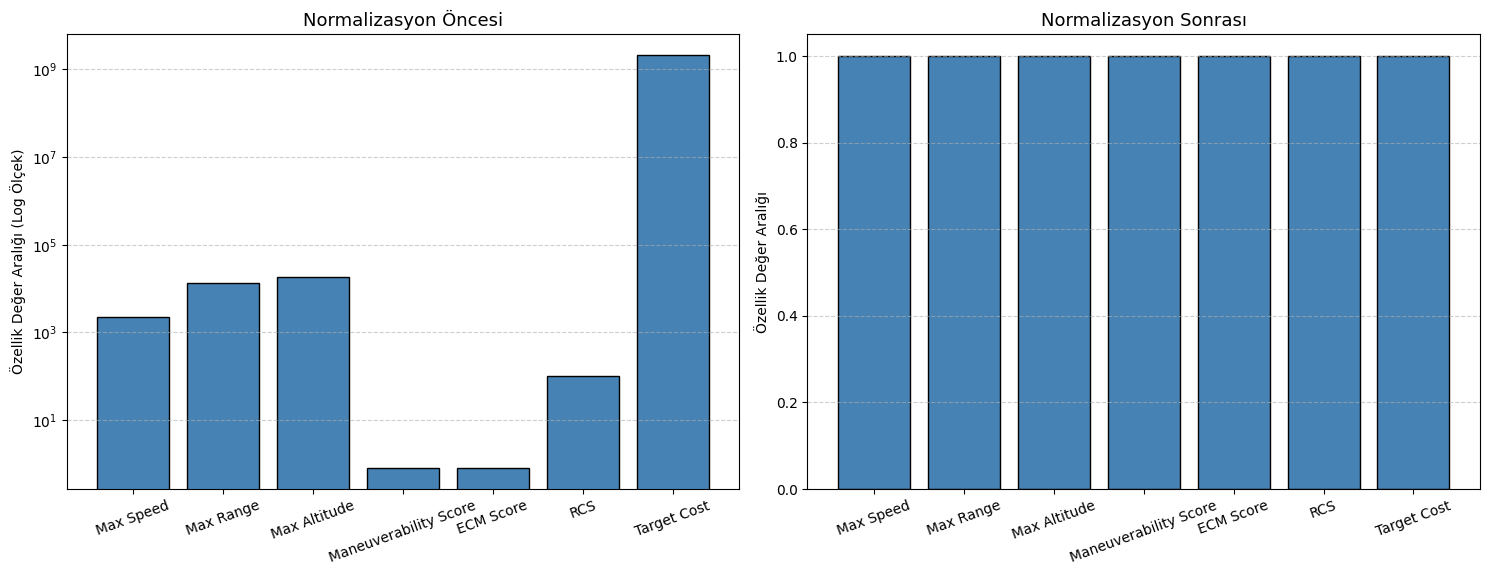

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

raw_aircraft = pd.read_excel("DATASET.xlsx", sheet_name="Aircraft")
norm_aircraft = pd.read_excel("Normalized_Aircraft_Data.xlsx")

df_unnormalized_numerical = df_model.copy()

feature_cols_raw = [
    "MaxSpeed",
    "MaxRange",
    "MaxAltitude",
    "ManeuverScore",
    "ECMScore",
    "RCS",
    "TargetCost"
]

feature_cols_norm = [
    "MaxSpeed",
    "MaxRange",
    "MaxAltitude",
    "ManeuverScore",
    "ECMScore",
    "RCS",
    "TargetCostScore"
]

feature_labels = [
    "Max Speed",
    "Max Range",
    "Max Altitude",
    "Maneuverability Score",
    "ECM Score",
    "RCS",
    "Target Cost"
]

raw_min = df_unnormalized_numerical[feature_cols_raw].min().values
raw_max = df_unnormalized_numerical[feature_cols_raw].max().values
raw_range = raw_max - raw_min

norm_min = norm_aircraft[feature_cols_norm].min().values
norm_max = norm_aircraft[feature_cols_norm].max().values
norm_range = norm_max - norm_min

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars1 = axes[0].bar(
    feature_labels,
    raw_range,
    color="steelblue",
    edgecolor="black"
)

axes[0].set_title("Normalizasyon Öncesi", fontsize=13)
axes[0].set_ylabel("Özellik Değer Aralığı (Log Ölçek)")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

bars2 = axes[1].bar(
    feature_labels,
    norm_range,
    color="steelblue",
    edgecolor="black"
)

axes[1].set_title("Normalizasyon Sonrası", fontsize=13)
axes[1].set_ylabel("Özellik Değer Aralığı")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

fig.suptitle(
    "",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [35]:
import pandas as pd
import numpy as np

# veriyi hazırla

df = df_step2.copy()
df_rl = df_norm.copy()

# ödül fonksiyonuna girdi olarak verilecek tehdit skorunun ağırlıklara göre hesaplanması
df_rl["RewardSignal"] = (
    0.372 * df_rl["MaxSpeed"] +
    0.008 * df_rl["MaxRange"] +
    0.294 * df_rl["MaxAltitude"] +
    0.147 * df_rl["ManeuverScore"] +
    0.132 * df_rl["ECMScore"] +
    0.047 * df_rl["RCS"]
)


# hava platformlarının tehdit skoruna göre sıralanması


df_rl_sorted = df_rl.sort_values(by="RewardSignal", ascending=False)

print(df_rl_sorted[["Name","RewardSignal"]])

                     Name  RewardSignal
2     Eurofighter Typhoon      0.985286
4           Su-27 Flanker      0.951432
6                    J-20      0.821074
5       F-35 Lightning II      0.816013
1          F-4 Phantom II      0.788372
3         Dassault Rafale      0.785293
0    F-16 Fighting Falcon      0.743712
9        Tu-160 Blackjack      0.703506
8              B-2 Spirit      0.527206
15  Bayraktar Akıncı TİHA      0.430160
18       Heron TP (Eitan)      0.430124
10                    H-6      0.427503
7     B-52 Stratofortress      0.381909
20           Storm Shadow      0.373281
16            MQ-9 Reaper      0.360350
19      Tomahawk Block IV      0.357298
21     Kh-55 Seyir Füzesi      0.251544
12             Mi-24 Hind      0.251338
11           AH-64 Apache      0.244917
17          Wing Loong II      0.209948
14              T129 ATAK      0.202373
13       UH-60 Black Hawk      0.193995


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


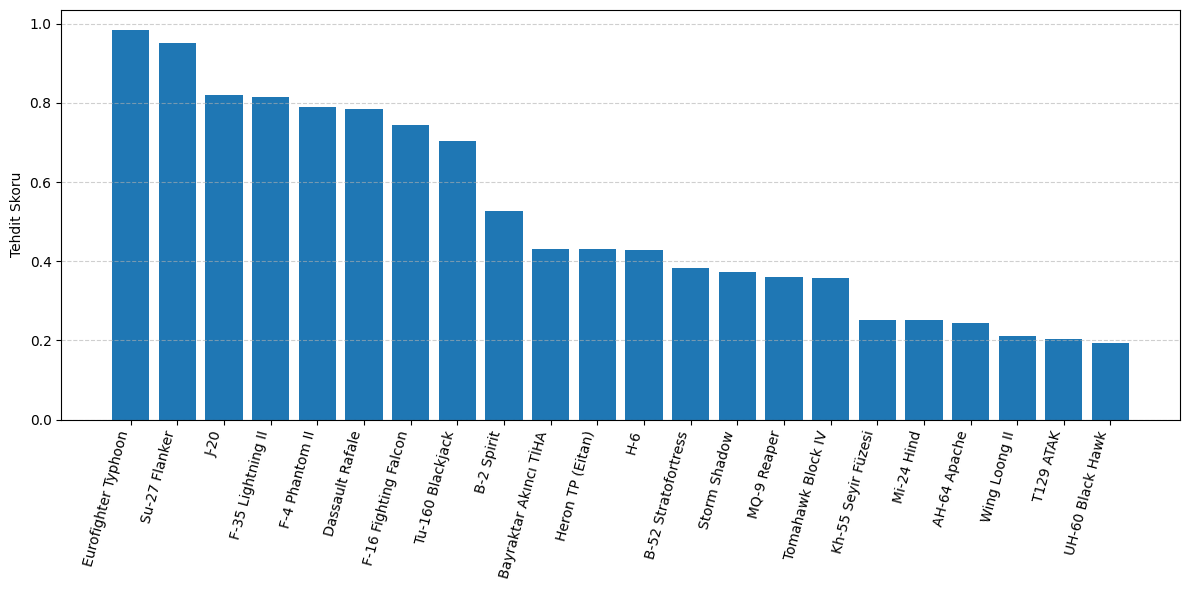

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



  Threat_Level  Count
0          Low     10
1       Medium      4
2         High      4
3     Critical      4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


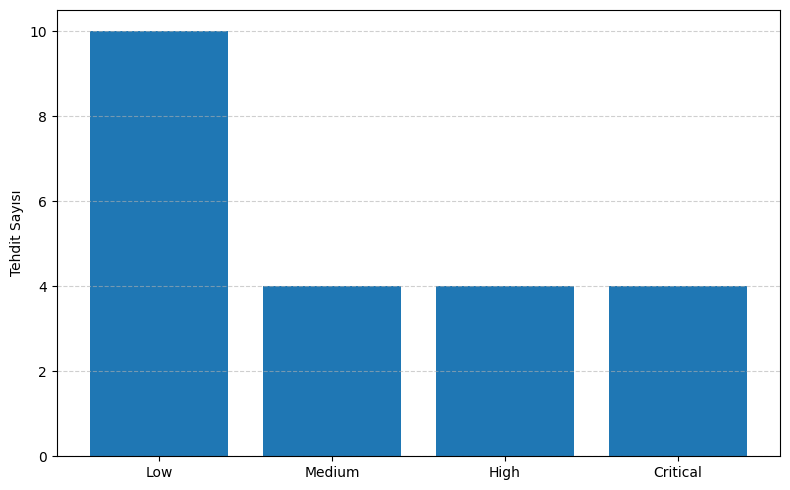


Dosyalar 'threat_analysis_outputs' klasörüne kaydedildi:
- threat_analysis_outputs/aircraft_top_threat_scores.png
- threat_analysis_outputs/aircraft_threat_level_distribution.xlsx
- threat_analysis_outputs/aircraft_threat_level_distribution.png
- threat_analysis_outputs/aircraft_threat_scores_sorted.xlsx


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import os

THREAT_OUTPUT_DIR = "threat_analysis_outputs"
os.makedirs(THREAT_OUTPUT_DIR, exist_ok=True)


# df_rl_sorted, önceki adımlarda oluşturulmuş RewardSignal'i içeren DataFrame
# Bu adımda doğrudan df_rl_sorted kullanılacak
df = df_rl_sorted.copy()

# 'RewardSignal' kolonunu 'Aircraft_Base_Threat_Score' olarak yeniden adlandır
df = df.rename(columns={"RewardSignal": "Aircraft_Base_Threat_Score"})

# Tehdit Seviyelerini Belirle
def get_threat_level(score):
    if score > 0.8:
        return "Critical"
    elif score > 0.6:
        return "High"
    elif score > 0.4:
        return "Medium"
    else:
        return "Low"

df["Aircraft_Threat_Level"] = df["Aircraft_Base_Threat_Score"].apply(get_threat_level)


df.columns = [str(col).strip() for col in df.columns]


df_sorted = df.sort_values(by="Aircraft_Base_Threat_Score", ascending=False).reset_index(drop=True)


top_n = len(df_sorted) # Tüm hava araçlarını göster
df_top = df_sorted.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(df_top["Name"], df_top["Aircraft_Base_Threat_Score"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Tehdit Skoru")
plt.title("")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(THREAT_OUTPUT_DIR, "aircraft_top_threat_scores.png"), dpi=300, bbox_inches="tight")
plt.show()



threat_distribution = (
    df["Aircraft_Threat_Level"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Critical"], fill_value=0)
    .reset_index()
)

threat_distribution.columns = ["Threat_Level", "Count"]

print("")
print(threat_distribution)


threat_distribution.to_excel(os.path.join(THREAT_OUTPUT_DIR, "aircraft_threat_level_distribution.xlsx"), index=False)


plt.figure(figsize=(8, 5))
plt.bar(threat_distribution["Threat_Level"], threat_distribution["Count"])
plt.ylabel("Tehdit Sayısı")
plt.title("")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(THREAT_OUTPUT_DIR, "aircraft_threat_level_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()


df_sorted.to_excel(os.path.join(THREAT_OUTPUT_DIR, "aircraft_threat_scores_sorted.xlsx"), index=False)

print(f"\nDosyalar '{THREAT_OUTPUT_DIR}' klasörüne kaydedildi:")
print(f"- {os.path.join(THREAT_OUTPUT_DIR, 'aircraft_top_threat_scores.png')}")
print(f"- {os.path.join(THREAT_OUTPUT_DIR, 'aircraft_threat_level_distribution.xlsx')}")
print(f"- {os.path.join(THREAT_OUTPUT_DIR, 'aircraft_threat_level_distribution.png')}")
print(f"- {os.path.join(THREAT_OUTPUT_DIR, 'aircraft_threat_scores_sorted.xlsx')}")

In [37]:

# Gerekli kütüphanelerin kurulumu (Colab / Jupyter ortamı için)
# sb3-contrib: MaskablePPO gibi gelişmiş RL algoritmaları içerir
# stable-baselines3: temel RL algoritmaları (PPO vb.)
# gymnasium: ortam (environment) tanımlamak için

!pip install -q sb3-contrib stable-baselines3 gymnasium matplotlib pandas openpyxl

import os
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt


# Reinforcement Learning (RL) kütüphaneleri
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from sb3_contrib.common.maskable.utils import get_action_masks
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback


# Genel deney (experiment) parametreleri
RUN_FULL_EVAL = True  # Eğitim sonrası tüm senaryolar üzerinde tam değerlendirme yapılacak mı
DEBUG_EVAL_SCENARIOS = 10  # Debug amaçlı çalıştırılacak senaryo sayısı (hızlı test için)
TOTAL_TIMESTEPS = 100000  # PPO ajanının toplam eğitim adım sayısı (learning süresi)
MAX_TARGETS = 10  # Her senaryoda maksimum hedef sayısı (state space boyutunu belirler)
N_SCENARIOS = 1000  # Toplam oluşturulacak senaryo sayısı
BASE_SEED = 42  # Rastgelelik için sabit seed (aynı sonuçları tekrar elde etmek için)

OUTPUT_DIR = "tewa_outputs"  # Çıktıların (grafik, log, excel vb.) kaydedileceği klasör adı

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [38]:
# Eksik sütun var mı kontrolü
required_rl_cols = {
    "Name",
    "RewardSignal",
    "ECMScore",
    "TargetCostScore"
}
required_step2_cols = {"Name", "MaxSpeed"}

if "df_rl" not in globals():
    raise ValueError("df_rl tanımlı değil. Önce tehdit skoru tablonu oluşturmalısın.")

if "df_step2" not in globals():
    raise ValueError("df_step2 tanımlı değil. Önce hız bilgisini içeren tabloyu yüklemelisin.")

if not required_rl_cols.issubset(df_rl.columns):
    raise ValueError(f"df_rl içinde şu sütunlar olmalı: {required_rl_cols}")

if not required_step2_cols.issubset(df_step2.columns):
    raise ValueError(f"df_step2 içinde şu sütunlar olmalı: {required_step2_cols}")

In [39]:
# TEMEL HEDEF HAVUZU

df_speed = df_step2[["Name", "MaxSpeed"]].copy()
df_speed = df_speed.rename(columns={"MaxSpeed": "Speed_kmh"})

df_target_pool = df_rl[
    ["Name", "RewardSignal", "ECMScore", "TargetCostScore"]
].copy()

df_target_pool = df_target_pool.merge(
    df_speed,
    on="Name",
    how="left"
)

if df_target_pool["Speed_kmh"].isna().any():
    missing_names = df_target_pool[
        df_target_pool["Speed_kmh"].isna()
    ]["Name"].tolist()

    raise ValueError(
        f"Şu hedefler için hız bilgisi bulunamadı: {missing_names}"
    )

print("\n=== TEMEL HEDEF HAVUZU ===")
print(df_target_pool.head(22))




=== TEMEL HEDEF HAVUZU ===
                     Name  RewardSignal  ECMScore  TargetCostScore  Speed_kmh
0    F-16 Fighting Falcon      0.743712      0.75         0.032873       2180
1          F-4 Phantom II      0.788372      0.25         0.001906       2370
2     Eurofighter Typhoon      0.985286      1.00         0.066222       2495
3         Dassault Rafale      0.785293      0.75         0.054312       1912
4           Su-27 Flanker      0.951432      1.00         0.016198       2500
5       F-35 Lightning II      0.816013      1.00         0.042401       1930
6                    J-20      0.821074      0.75         0.051929       2100
7     B-52 Stratofortress      0.381909      0.25         0.039543       1046
8              B-2 Spirit      0.527206      0.75         1.000000       1010
9        Tu-160 Blackjack      0.703506      0.75         0.166270       2220
10                    H-6      0.427503      0.25         0.018580       1050
11           AH-64 Apache      0.244

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [40]:

# ==========================
# SENARYO ÜRETİMİ FONKSİYONU
# ==========================

def generate_random_scenario(df_target_pool, min_targets=3, max_targets=10, seed=None):
    rng = np.random.default_rng(seed)  # Tekrarlanabilir rastgele sayı üreticisi oluştur
    df_pool = df_target_pool.copy()    # Orijinal veri setini korumak için kopyasını al

    n_targets = int(rng.integers(min_targets, max_targets + 1))  # Senaryodaki hedef sayısını belirle

    selected_idx = rng.choice(          # Hedef havuzundan rastgele hedef seç
        df_pool.index,
        size=n_targets,
        replace=False                   # Aynı hedef bir senaryoda iki kez seçilemez
    )

    df_scenario = df_pool.loc[selected_idx].copy().reset_index(drop=True)  # Seçilen hedefleri yeni senaryo tablosuna aktar

    mandatory_zones = ["short", "medium", "long"]  # Her senaryoda en az bir kısa, orta ve uzun menzil hedef bulunacak

    remaining_zones = []  # Fazladan üretilecek hedeflerin menzil bölgelerini tutacak liste

    if n_targets > 3:  # Eğer 3'ten fazla hedef varsa
        remaining_zones = list(
            rng.choice(
                ["short", "medium", "long"],  # Bölge seçenekleri
                size=n_targets - 3,           # Kalan hedef sayısı kadar bölge üret
                p=[0.34, 0.33, 0.33]          # Bölge olasılıkları
            )
        )

    zones = mandatory_zones + remaining_zones  # Tüm bölgeleri birleştir
    rng.shuffle(zones)                         # Hedeflere rastgele dağıtmak için karıştır

    distances = []   # Hedef mesafeleri
    altitudes = []   # Hedef irtifaları
    iff_list = []    # Dost-düşman bilgileri
    speed_list = []  # Hedef hızları

    for idx, row in df_scenario.iterrows():  # Her hedef için senaryo parametreleri üret

        zone = zones[idx]  # İlgili hedefin bölgesi

        # ==========================
        # MESAFE VE İRTİFA ÜRETİMİ
        # ==========================

        if zone == "short":  # Kısa menzil bölgesi
            d = rng.uniform(3, 15)       # km
            alt = rng.uniform(100, 6000) # metre

        elif zone == "medium":  # Orta menzil bölgesi
            d = rng.uniform(3, 25)
            alt = rng.uniform(1000, 12500)

        else:  # Uzun menzil bölgesi
            d = rng.uniform(20, 150)
            alt = rng.uniform(3000, 20000)

        # ==========================
        # IFF (DOST-DÜŞMAN TANIMLAMA)
        # ==========================

        iff = rng.choice(
            [1, 2, 0],                  # 1=Dost, 2=Düşman, 0=Bilinmeyen
            p=[0.10, 0.70, 0.20]        # Olasılık dağılımı
        )

        # ==========================
        # HIZ ÜRETİMİ
        # ==========================

        speed_noise = rng.uniform(0.88, 1.12)   # ±%12 rastgele sapma oluştur
        spd = float(row["Speed_kmh"]) * speed_noise  # Temel hızı varyasyonla güncelle

        distances.append(round(float(d), 2))     # Mesafeyi listeye ekle
        altitudes.append(round(float(alt), 2))   # İrtifayı listeye ekle
        iff_list.append(int(iff))                # IFF bilgisini ekle
        speed_list.append(round(float(spd), 2))  # Hızı ekle

    # ==========================
    # SENARYO TABLOSUNA EKLE
    # ==========================

    df_scenario["Distance_km"] = distances  # Hedef mesafesi
    df_scenario["Altitude_m"] = altitudes   # Hedef irtifası
    df_scenario["IFF"] = iff_list           # Dost-düşman bilgisi
    df_scenario["Speed_kmh"] = speed_list   # Hedef hızı

    # ==========================
    # GEREKLİ SÜTUNLARI SEÇ
    # ==========================

    df_scenario = df_scenario[
        [
            "Name",              # Hedef adı
            "RewardSignal",      # Tehdit skoru
            "TargetCostScore",   # Hedefin normalize edilmiş maliyet skoru
            "Distance_km",       # Hedef mesafesi
            "Altitude_m",        # Hedef irtifası
            "ECMScore",          # Elektronik harp seviyesi
            "Speed_kmh",         # Hedef hızı
            "IFF"                # Dost-düşman bilgisi
        ]
    ].copy()

    # Tehdit skoruna göre büyükten küçüğe sırala
    df_scenario = df_scenario.sort_values(
        by="RewardSignal",
        ascending=False
    ).reset_index(drop=True)

    return df_scenario  # Oluşturulan senaryoyu döndür


# ==========================
# TOPLU SENARYO ÜRETİMİ
# ==========================

def build_scenario_dataset(
    df_target_pool,
    n_scenarios=1000,
    min_targets=3,
    max_targets=10,
    base_seed=42
):
    scenarios = []  # Tüm senaryoları saklayacak liste

    for i in range(n_scenarios):  # Belirlenen sayıda senaryo üret
        sc = generate_random_scenario(
            df_target_pool=df_target_pool,
            min_targets=min_targets,
            max_targets=max_targets,
            seed=base_seed + i      # Her senaryoda farklı seed kullan
        )

        scenarios.append(sc)        # Oluşturulan senaryoyu listeye ekle

    return scenarios                # Tüm senaryoları döndür


# ==========================
# TRAIN / VALIDATION / TEST AYRIMI
# ==========================

def split_scenarios(
    scenarios,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42
):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9  # Oranların toplamı 1 olmalı

    rng = np.random.default_rng(seed)  # Rastgele sayı üreticisi oluştur

    idx = np.arange(len(scenarios))    # Senaryo indekslerini oluştur
    rng.shuffle(idx)                   # Karıştır

    n_total = len(scenarios)           # Toplam senaryo sayısı
    n_train = int(n_total * train_ratio)  # Eğitim kümesi boyutu
    n_val = int(n_total * val_ratio)      # Validasyon kümesi boyutu

    train_idx = idx[:n_train]                      # Eğitim indeksleri
    val_idx = idx[n_train:n_train + n_val]         # Validasyon indeksleri
    test_idx = idx[n_train + n_val:]               # Test indeksleri

    train_scenarios = [scenarios[i] for i in train_idx]  # Eğitim senaryoları
    val_scenarios = [scenarios[i] for i in val_idx]      # Validasyon senaryoları
    test_scenarios = [scenarios[i] for i in test_idx]    # Test senaryoları

    return train_scenarios, val_scenarios, test_scenarios


In [41]:
# ACTION MASK
# Bu fonksiyon, ortamdan (environment) geçerli aksiyonları (valid actions) alır
# MaskablePPO algoritması her adımda bu fonksiyonu çağırır

def mask_fn(env):
    return env.action_masks()

In [42]:
class MultiTargetTEWAEnv(gym.Env):  # Gym tabanlı özel RL ortamı tanımlanır
    metadata = {"render_modes": []}

    def __init__(self, scenarios, max_targets=10):
        super().__init__()

        self.scenarios = scenarios # Tüm senaryolar tutulur
        self.max_targets = max_targets # Maksimum hedef sayısı
        self.current_scenario_idx = -1
    # SİSTEM TANIMLARI
        self.systems = [
            {
                "name": "HİSAR A",
                "min_range": 3.0,
                "max_range": 15.0,
                "max_altitude": 6000.0,
                "max_engagements": 6,
                "max_missiles": 12,
                "cost": 1.0,
                "base_pk": 0.62,
                "ecm_resistance": 0.50
            },
            {
                "name": "HİSAR O+",
                "min_range": 3.0,
                "max_range": 25.0,
                "max_altitude": 12500.0,
                "max_engagements": 6,
                "max_missiles": 18,
                "cost": 2.0,
                "base_pk": 0.78,
                "ecm_resistance": 0.85
            },
            {
                "name": "SİPER",
                "min_range": 20.0,
                "max_range": 150.0,
                "max_altitude": 20000.0,
                "max_engagements": 10,
                "max_missiles": 20,
                "cost": 3.0,
                "base_pk": 0.84,
                "ecm_resistance": 0.85
            }
        ]

        self.num_systems = len(self.systems) # Toplam sistem sayısı

        self.actions_per_target = self.num_systems + 1  # +1 = NO-ENGAGE
        self.action_space = spaces.Discrete(self.max_targets * self.actions_per_target)
         # Her hedef için 4 aksiyon

        # target başına 9 özellik:
        # RewardSignal, Distance, Altitude, ECM, Detected, IFF, TTI, Assigned, FeasibleCount
        obs_len = self.max_targets * 9 + self.num_systems * 3 + 1
        self.observation_space = spaces.Box(
            low=np.zeros(obs_len, dtype=np.float32),
            high=np.ones(obs_len, dtype=np.float32),
            dtype=np.float32
        )
       # Ajanın geçersiz veya maskelenmiş bir aksiyonu seçmesi durumunda uygulanacak ceza değeridir
        self.invalid_action_penalty = -12.0

        self.df_targets = None
        self.num_targets = 0
        self.remaining_engagements = None
        self.remaining_missiles = None
        self.assigned = None
        self.decisions = None
        self.step_logs = None

# Aktif senaryodaki hedefleri tutacak DataFrame başlangıçta boş tanımlanır
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_scenario_idx = (self.current_scenario_idx + 1) % len(self.scenarios)
        self.df_targets = self.scenarios[self.current_scenario_idx].copy().reset_index(drop=True)
        self.num_targets = len(self.df_targets)

        # Her hedef için Time-To-Impact değeri saniye cinsinden hesaplanır
        # TTI = Mesafe / Hız * 3600 formülü kullanılır
        self.df_targets["TTI_sec"] = self.df_targets.apply(
            lambda row: self._compute_tti_seconds(row["Distance_km"], row["Speed_kmh"]),
            axis=1
        )

        min_tti = self.df_targets["TTI_sec"].min()
        # Senaryo içindeki en düşük TTI değeri alınır
        # En düşük TTI, zamansal olarak en acil hedefi temsil eder

        max_tti = self.df_targets["TTI_sec"].max()
        # Senaryo içindeki en düşük TTI değeri alınır
        # En düşük TTI, zamansal olarak en acil hedefi temsil eder
        self.df_targets["TTI_score"] = self.df_targets["TTI_sec"].apply(
            lambda x: self._normalize_tti_score(x, min_tti, max_tti)
        )
        # Her sistemin kalan angajman kapasitesi maksimum kapasiteyle başlat
        self.remaining_engagements = [s["max_engagements"] for s in self.systems]
        # Her sistemin kalan angajman kapasitesi maksimum kapasiteyle başlat
        self.remaining_missiles = [s["max_missiles"] for s in self.systems]
        self.assigned = [False] * self.num_targets
        self.decisions = [None] * self.num_targets
        self.step_logs = []

        return self._get_state(), {
            "scenario_size": self.num_targets,
            "scenario_index": self.current_scenario_idx
        }

    def _get_state(self): #  Ajanın gözlemleyeceği mevcut ortam durumunu oluşturan fonksiyondur.
        target_features = []  # Hedeflere ait tüm durum özelliklerinin tutulacağı boş liste oluşturulur.


        for i in range(self.max_targets):
            if i < self.num_targets:
                tgt = self.df_targets.iloc[i]
                assigned = 1.0 if self.assigned[i] else 0.0 # Hedef daha önce angaje edilmişse 1, edilmemişse 0
                feasible_count = self._count_feasible_systems_for_target(i) # Hedefe angaje olabilecek uygun sistem sayısını hesapla
                # İlgili hedefe ait özellikler durum vektörüne eklenir.

                target_features.extend([
                    float(np.clip(tgt["RewardSignal"], 0.0, 1.0)),
                    float(np.clip(tgt["Distance_km"] / 150.0, 0.0, 1.0)),
                    float(np.clip(tgt["Altitude_m"] / 20000.0, 0.0, 1.0)),
                    float(np.clip(tgt["ECMScore"], 0.0, 1.0)),
                    float(np.clip(tgt["TargetCostScore"], 0.0, 1.0)),
                    float(np.clip(tgt["IFF"] / 2.0, 0.0, 1.0)),
                    float(np.clip(tgt["TTI_score"], 0.0, 1.0)),
                    assigned,
                    float(np.clip(feasible_count / self.num_systems, 0.0, 1.0))
                ])



            else:
                target_features.extend([0.0] * 9)

        system_features = []
        for j in range(self.num_systems):
            system = self.systems[j]
            system_features.append(self.remaining_engagements[j] / system["max_engagements"])
        for j in range(self.num_systems):
            system = self.systems[j]
            system_features.append(self.remaining_missiles[j] / system["max_missiles"])
        for j in range(self.num_systems):
            system = self.systems[j]
            system_features.append(np.clip(system["cost"] / 3.0, 0.0, 1.0))

        active_ratio = sum([0 if a else 1 for a in self.assigned[:self.num_targets]]) / max(1, self.num_targets)

        return np.array(target_features + system_features + [active_ratio], dtype=np.float32)
# Hedefin mevcut hız ve mesafesine göre time-to-impact değerini saniye cinsinden hesaplar.
    def _compute_tti_seconds(self, distance_km, speed_kmh):
        if speed_kmh <= 0:
            return 999999.0
        return (float(distance_km) / float(speed_kmh)) * 3600.0

    def _normalize_tti_score(self, tti_sec, min_tti, max_tti):
        if max_tti == min_tti:
            return 1.0
        return 1.0 - ((tti_sec - min_tti) / (max_tti - min_tti))


    def _is_friendly(self, iff_value):  # Hedefin dost unsur olup olmadığını kontrol eder.
        return int(iff_value) == 1

    def _is_hostile_or_unknown(self, iff_value): # Hedefin düşman veya kimliği bilinmeyen unsur olup olmadığını kontrol eder.
        return int(iff_value) in [0, 2]

    def _is_in_range(self, distance, system): # edefin seçilen sistemin menzil zarfı içinde olup olmadığını kontrol eder.
        return system["min_range"] <= distance <= system["max_range"]

    def _is_in_altitude(self, altitude, system): # Hedef irtifasının sistemin angajman irtifa sınırı içinde olup olmadığını kontrol eder
        return altitude <= system["max_altitude"]

    def _has_engagement_capacity(self, system_idx): # İlgili sistemin angajman kapasitesinin kalıp kalmadığını kontrol eder.
        return self.remaining_engagements[system_idx] > 0

    def _has_missile_capacity(self, system_idx): # İlgili sistemin mühimmat kapasitesinin kalıp kalmadığını kontrol eder.
        return self.remaining_missiles[system_idx] > 0

    def _decode_action(self, action): # Aksiyonun hangi hedefe ait olduğu hesaplanır.
        target_idx = int(action // self.actions_per_target)
        local_action = int(action % self.actions_per_target)
        return target_idx, local_action

    def _encode_action(self, target_idx, local_action):
        return int(target_idx * self.actions_per_target + local_action)

    def _system_name(self, idx):
        return self.systems[idx]["name"]

    def _count_feasible_systems_for_target(self, target_idx): # Belirli bir hedef için uygun angajman sistemlerinin sayısını hesaplar.
        if target_idx >= self.num_targets:
            return 0

        tgt = self.df_targets.iloc[target_idx]
        distance = float(tgt["Distance_km"])
        altitude = float(tgt["Altitude_m"])

        iff_value = int(tgt["IFF"])

        count = 0
        for sys_idx, system in enumerate(self.systems): # Tüm hava savunma sistemleri tek tek kontrol edilir.
            valid = ( # Sistemin hedefe angaje olup olamayacağı tüm kısıtlarla değerlendirilir.

                self._is_hostile_or_unknown(iff_value)
                and self._is_in_range(distance, system)
                and self._is_in_altitude(altitude, system)
                and self._has_engagement_capacity(sys_idx)
                and self._has_missile_capacity(sys_idx)
            )
            if valid:  # Eğer tüm şartlar sağlanıyorsa sistem uygun kabul edilir.
                count += 1
        return count

    def _is_action_valid(self, target_idx, local_action): # Seçilen aksiyonun geçerli olup olmadığını kontrol eder.
        if target_idx >= self.num_targets:
            return False
        if self.assigned[target_idx]: # Hedef daha önce bir sisteme atanmışsa tekrar angaje edilmemelidir.
            return False

        tgt = self.df_targets.iloc[target_idx]
        distance = float(tgt["Distance_km"])
        altitude = float(tgt["Altitude_m"])

        iff_value = int(tgt["IFF"])

        if local_action == self.num_systems:
            return True

        system = self.systems[local_action] # Seçilen sistemin hedefe angaje olup olamayacağı operasyonel kısıtlarla kontrol edilir.
        valid = (

            self._is_hostile_or_unknown(iff_value)
            and self._is_in_range(distance, system)
            and self._is_in_altitude(altitude, system)
            and self._has_engagement_capacity(local_action)
            and self._has_missile_capacity(local_action)
        )
        return bool(valid)

    def action_masks(self):    # Her aksiyon için geçerlilik kontrolü yapılır
        mask = np.zeros(self.action_space.n, dtype=bool)

        for tgt_idx in range(self.max_targets):
            if tgt_idx >= self.num_targets:
                continue
            if self.assigned[tgt_idx]:
                continue

            for local_action in range(self.actions_per_target):
                flat_action = self._encode_action(tgt_idx, local_action)
                mask[flat_action] = self._is_action_valid(tgt_idx, local_action)

        return mask

    def _compute_pkill(self, target, system_idx): # Seçilen hedef-sistem çifti için tahmini öldürme/başarı olasılığını hesaplar.
        system = self.systems[system_idx]

        target_ecm = float(target["ECMScore"])
        distance = float(target["Distance_km"])
        altitude = float(target["Altitude_m"])

        rmin = system["min_range"]
        rmax = system["max_range"]
        center = 0.5 * (rmin + rmax)
        half_span = max((rmax - rmin) / 2.0, 1e-6)

        distance_fit = 1.0 - min(abs(distance - center) / half_span, 1.0)

        altitude_fit = 1.0 - min(altitude / max(system["max_altitude"], 1.0), 1.0)
        altitude_fit = max(0.20, altitude_fit)

        ecm_penalty = 0.30 * max(0.0, target_ecm - system["ecm_resistance"] + 0.2)

        pkill = (  # Nihai öldürme olasılığı sistemin temel başarı değeri, mesafe, irtifa ve ECM etkisiyle hesaplanır.
        system["base_pk"]  # Sistemin temel öldürme/başarı olasılığıdır.
        + 0.08 * distance_fit  # Hedef ideal menzil bölgesine yakınsa Pkill değerine katkı sağlar.
        + 0.06 * altitude_fit  # Hedef sistemin irtifa kabiliyetine uygunsa Pkill değerine katkı sağlar.
        - ecm_penalty  # Hedefin ECM etkisi Pkill değerinden düşülür.
    )

        return float(np.clip(pkill, 0.20, 0.95))

    def _resource_pressure(self, system_idx): # Seçilen sistem üzerindeki kaynak baskısını hesaplar.
        system = self.systems[system_idx]
        engagement_ratio = self.remaining_engagements[system_idx] / system["max_engagements"]
        missile_ratio = self.remaining_missiles[system_idx] / system["max_missiles"]
        return 1.0 - 0.5 * (engagement_ratio + missile_ratio)

    def _layer_doctrine_bonus(self, target_idx, local_action): # Seçilen hedef-sistem eşleşmesinin katmanlı savunma doktrinine uygunluğuna göre ek ödül hesaplar.
        if local_action == self.num_systems:
            return 0.0

        tgt = self.df_targets.iloc[target_idx]
        distance = float(tgt["Distance_km"])

        # Doktrinel tercih:
        # 3-15 km   -> HİSAR A
        # 15-25 km  -> HİSAR O+
        # 25+ km    -> SİPER

        if 3.0 <= distance <= 15.0:
            if local_action == 0:   # HİSAR A
                return 3.5
            elif local_action == 1: # HİSAR O+
                return -2.5
            elif local_action == 2: # SİPER
                return -4.0

        elif 15.0 < distance <= 25.0:
            if local_action == 1:   # HİSAR O+
                return 2.5
            elif local_action == 2: # SİPER
                return -1.5
            elif local_action == 0: # HİSAR A
                return -3.5

        else:
            if local_action == 2:   # SİPER
                return 3.0
            elif local_action == 1: # HİSAR O+
                return -2.0
            elif local_action == 0: # HİSAR A
                return -4.0

        return 0.0

    def _compute_reward(self, target_idx, local_action): # Ajanın seçtiği hedef-aksiyon çifti için ödül/ceza değerini hesaplar.
        tgt = self.df_targets.iloc[target_idx]

        threat_score = float(tgt["RewardSignal"])
        tti_score = float(tgt["TTI_score"])
        target_cost = float(tgt["TargetCostScore"])
        iff_value = int(tgt["IFF"])


        feasible_count = self._count_feasible_systems_for_target(target_idx)

        if local_action == self.num_systems:  # Eğer seçilen aksiyon NO-ENGAGE yani angaje olmama kararı ise bu blok çalışır.
            if self._is_friendly(iff_value):
                return 4.0

            if feasible_count == 0:  # Hedefe angaje olabilecek uygun sistem yoksa angaje olmamak doğru karardır.
                return 1.5

            return -(  # Eğer hedef angaje edilebilir durumdayken NO-ENGAGE seçilmişse ceza uygulanır
                3.0
                + 6.0 * threat_score
                + 5.0 * tti_score
                + 4.0 * target_cost

            )

        system = self.systems[local_action]
        p_kill = self._compute_pkill(tgt, local_action)
        resource_pressure = self._resource_pressure(local_action)
        cost_norm = float(system["cost"]) / 3.0
        doctrine_bonus = self._layer_doctrine_bonus(target_idx, local_action)

        if self._is_friendly(iff_value): # Eğer hedef dost unsur ise angajman kesinlikle istenmeyen bir karardır.
            return -15.0


        if not self._is_action_valid(target_idx, local_action): # Seçilen angajman menzil, irtifa, kapasite veya mühimmat açısından geçerli değilse bu blok çalışır.
            return -10.0

        reward = 0.0

        # Ana görev katkıları
        reward += 5.0 * threat_score
        reward += 4.0 * tti_score
        reward += 3.0 * target_cost


        reward += 2.5 * p_kill


        reward -= 2.2 * cost_norm
        reward -= 1.4 * resource_pressure

        # ECM uyumsuzluğu
        reward -= 1.0 * float(tgt["ECMScore"]) * (1.0 - system["ecm_resistance"])

        # Katman doktrini
        reward += doctrine_bonus

        # Düşük tehditte üst katman kullanımını azalt
        if threat_score < 0.40 and local_action == 2:
            reward -= 2.5
        if threat_score < 0.30 and local_action == 1:
            reward -= 1.5

        distance = float(tgt["Distance_km"])

        # HİSAR A yalnız kısa menzilde güçlü biçimde ödüllendirilsin
        if 3.0 <= distance <= 15.0 and local_action == 0:
            reward += 2.0

        # HİSAR O+ bonusu sadece orta menzile çekilsin
        if 15.0 < distance <= 25.0 and local_action == 1:
            reward += 1.2

        # SİPER bonusu uzun menzilde verilsin
        if distance > 25.0 and local_action == 2:
            reward += 1.2

        return float(reward)

    def step(self, action):  # Ajanın seçtiği aksiyonu ortamda uygulayan ve bir sonraki durumu döndüren temel step fonksiyonudur.
        target_idx, local_action = self._decode_action(int(action))
        done = False
        truncated = False

        current_mask = self.action_masks()
        if not current_mask[int(action)]:
            reward = self.invalid_action_penalty
            return self._get_state(), reward, done, truncated, {
                "constraint_violation": "Masked invalid action"
            }

        tgt = self.df_targets.iloc[target_idx]
        reward = self._compute_reward(target_idx, local_action)

        if local_action != self.num_systems:
            self.remaining_engagements[local_action] -= 1
            self.remaining_missiles[local_action] -= 1
            decision = self._system_name(local_action)
        else:
            decision = "NO-ENGAGE"

        self.decisions[target_idx] = decision
        self.assigned[target_idx] = True

        self.step_logs.append({
        "TargetName": tgt["Name"],
        "RewardSignal": float(tgt["RewardSignal"]),
        "Distance_km": float(tgt["Distance_km"]),
        "Altitude_m": float(tgt["Altitude_m"]),
        "ECMScore": float(tgt["ECMScore"]),
        "IFF": int(tgt["IFF"]),
        "TargetCostScore": float(tgt["TargetCostScore"]),
        "Speed_kmh": float(tgt["Speed_kmh"]),
        "TTI_sec": float(tgt["TTI_sec"]),
        "TTI_score": float(tgt["TTI_score"]),
        "ChosenAction": decision,
        "StepReward": float(reward)
         })

        if all(self.assigned[:self.num_targets]): #Mevcut senaryodaki tüm hedefler için karar verilmişse bu blok çalışır.
            done = True

        return self._get_state(), float(reward), done, truncated, {
            "decision": f"{tgt['Name']} -> {decision}"
        }

In [43]:

# CALLBACK
 # Stable-Baselines3 eğitim sürecinde özel metrikleri kaydetmek için callback sınıfı tanımlanır
class RewardLoggerCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []          # ham toplam episode ödülü
        self.episode_avg_rewards = []      # episode başına ortalama ödül
        self.episode_lengths = []          # her episode'daki adım/hedef sayısı

        self.current_episode_reward = 0.0
        self.current_episode_steps = 0

        self.policy_loss = []
        self.value_loss = []
        self.entropy_loss = []
        self.total_loss = []

    def _on_step(self) -> bool:
        reward = float(self.locals["rewards"][0])
        done = bool(self.locals["dones"][0])

        self.current_episode_reward += reward
        self.current_episode_steps += 1

        if done:
            self.episode_rewards.append(self.current_episode_reward)
            self.episode_lengths.append(self.current_episode_steps)

            avg_reward = self.current_episode_reward / max(1, self.current_episode_steps)
            self.episode_avg_rewards.append(avg_reward)

            self.current_episode_reward = 0.0
            self.current_episode_steps = 0

        return True

    def _on_rollout_end(self) -> None:
        logger_dict = self.model.logger.name_to_value

        if "train/policy_gradient_loss" in logger_dict:
            self.policy_loss.append(float(logger_dict["train/policy_gradient_loss"]))

        if "train/value_loss" in logger_dict:
            self.value_loss.append(float(logger_dict["train/value_loss"]))

        if "train/entropy_loss" in logger_dict:
            self.entropy_loss.append(float(logger_dict["train/entropy_loss"]))

        if "train/loss" in logger_dict:
            self.total_loss.append(float(logger_dict["train/loss"]))



In [44]:
def get_feasible_systems_initial(raw_env, target_row):
    feasible_systems = []


    iff_value = int(target_row["IFF"])
    distance = float(target_row["Distance_km"])
    altitude = float(target_row["Altitude_m"])


    if iff_value == 1:
        return feasible_systems

    for system in raw_env.systems:
        in_range = system["min_range"] <= distance <= system["max_range"]
        in_altitude = altitude <= system["max_altitude"]

        if in_range and in_altitude:
            feasible_systems.append(system["name"])

    return feasible_systems


def get_expected_action(raw_env, target_row):
    feasible_systems = get_feasible_systems_initial(raw_env, target_row);


    iff_value = int(target_row["IFF"])
    distance = float(target_row["Distance_km"])

    if iff_value == 1:
        return "NO-ENGAGE", 0


    if len(feasible_systems) == 0:
        return "NO-ENGAGE", 0


    # 0 -> Angaje edilmemeli / fizibil değil
    # 1 -> Orta/uzun katman fizibil
    # 2 -> Kısa katman dahil fizibil

    if 3.0 <= distance <= 15.0:
        if "HİSAR A" in feasible_systems:
            return "HİSAR A", 2
        elif "HİSAR O+" in feasible_systems:
            return "HİSAR O+", 1
        elif "SİPER" in feasible_systems:
            return "SİPER", 1
        else:
            return "NO-ENGAGE", 0

    elif 15.0 < distance <= 25.0:
        if "HİSAR O+" in feasible_systems:
            return "HİSAR O+", 2
        elif "SİPER" in feasible_systems:
            return "SİPER", 1
        elif "HİSAR A" in feasible_systems:
            return "HİSAR A", 1
        else:
            return "NO-ENGAGE", 0

    else:
        if "SİPER" in feasible_systems:
            return "SİPER", 1
        elif "HİSAR O+" in feasible_systems:
            return "HİSAR O+", 1
        elif "HİSAR A" in feasible_systems:
            return "HİSAR A", 1
        else:
            return "NO-ENGAGE", 0


def is_operationally_correct(chosen_action, expected_action):
    return 1 if str(chosen_action) == str(expected_action) else 0


def evaluate_scenarios(model, scenarios, env_name="SET", save_txt=False):
    episode_rewards = []
    decision_rows = []

    txt_dir = os.path.join(OUTPUT_DIR, f"{env_name.lower()}_scenario_reports")
    if save_txt:
        os.makedirs(txt_dir, exist_ok=True)

    system_names = None

    for sc_idx, scenario in enumerate(scenarios):
        if sc_idx % 10 == 0:
            print(f"{env_name} senaryo {sc_idx + 1}/{len(scenarios)}")

        raw_env = MultiTargetTEWAEnv([scenario], max_targets=MAX_TARGETS)
        env = ActionMasker(raw_env, mask_fn)

        obs, info = env.reset()
        done = False
        total_reward = 0.0

        system_names = [s["name"] for s in raw_env.systems]

        initial_target_info = []
        for i in range(raw_env.num_targets):
            tgt0 = raw_env.df_targets.iloc[i].copy()
            feasible_systems_initial = get_feasible_systems_initial(raw_env, tgt0)
            expected_action, feasible_initial_code = get_expected_action(raw_env, tgt0)

            initial_target_info.append({
                "FeasibleSystemsInitial": feasible_systems_initial,
                "FeasibleSystemCountInitial": len(feasible_systems_initial),
                "ExpectedAction": expected_action,
                "FeasibleInitial": feasible_initial_code
            })

        while not done:
            action, _ = model.predict(
                obs,
                deterministic=True,
                action_masks=get_action_masks(env)
            )
            obs, reward, done, truncated, step_info = env.step(action)
            total_reward += reward

        episode_rewards.append(total_reward)

        scenario_df = raw_env.df_targets.copy()
        scenario_df["ChosenAction"] = raw_env.decisions

        operational_correct_list = []

        for i in range(raw_env.num_targets):
            tgt = raw_env.df_targets.iloc[i]
            chosen_action = raw_env.decisions[i]

            feasible_initial = initial_target_info[i]["FeasibleInitial"]
            feasible_systems_initial = initial_target_info[i]["FeasibleSystemsInitial"]
            feasible_count_initial = initial_target_info[i]["FeasibleSystemCountInitial"]
            expected_action = initial_target_info[i]["ExpectedAction"]

            p_kill_estimate = 0.0
            if chosen_action in system_names:
                chosen_sys_idx = system_names.index(chosen_action)
                p_kill_estimate = raw_env._compute_pkill(tgt, chosen_sys_idx)

            operational_correct = is_operationally_correct(chosen_action, expected_action)
            operational_correct_list.append(operational_correct)

            hostile_feasible_initial = 1 if (
                int(tgt["IFF"]) in [0, 2] and
                feasible_count_initial > 0
            ) else 0

            correct_friendly_hold = 1 if (
                int(tgt["IFF"]) == 1 and chosen_action == "NO-ENGAGE"
            ) else 0

            row = {
                "ScenarioSet": env_name,
                "ScenarioIdx": sc_idx + 1,
                "TargetName": tgt["Name"],
                "RewardSignal": float(tgt["RewardSignal"]),
                "TargetCostScore": float(tgt["TargetCostScore"]),
                "Distance_km": float(tgt["Distance_km"]),
                "Altitude_m": float(tgt["Altitude_m"]),
                "ECMScore": float(tgt["ECMScore"]),
                "Speed_kmh": float(tgt["Speed_kmh"]),
                "IFF": int(tgt["IFF"]),
                "TTI_sec": float(tgt["TTI_sec"]),
                "TTI_score": float(tgt["TTI_score"]),
                "FeasibleInitial": int(feasible_initial),
                "FeasibleSystemCountInitial": int(feasible_count_initial),
                "FeasibleSystemsInitial": ", ".join(feasible_systems_initial) if feasible_systems_initial else "NONE",
                "ExpectedAction": expected_action,
                "ChosenAction": chosen_action,
                "PkillEstimate": float(p_kill_estimate),
                "Engaged": 0 if chosen_action == "NO-ENGAGE" else 1,
                "HostileFeasibleInitial": int(hostile_feasible_initial),
                "CorrectFriendlyHold": int(correct_friendly_hold),
                "OperationalCorrect": int(operational_correct)
            }

            decision_rows.append(row)

        scenario_operational_accuracy = float(np.mean(operational_correct_list)) if len(operational_correct_list) > 0 else 0.0

        if save_txt:
            txt_path = os.path.join(txt_dir, f"{env_name.lower()}_scenario_{sc_idx+1:03d}.txt")
            with open(txt_path, "w", encoding="utf-8") as f:
                f.write(f"{env_name} SENARYO ANGAJMAN SONUÇLARI\n")
                f.write("=" * 140 + "\n\n")
                f.write(f"SENARYO NO              : {sc_idx + 1}\n")
                f.write(f"ScenarioSet             : {env_name}\n")
                f.write(f"Toplam Hedef Sayısı     : {raw_env.num_targets}\n")
                f.write(f"Episode Toplam Reward   : {total_reward:.4f}\n")
                f.write(f"Operational Accuracy    : {scenario_operational_accuracy:.4f}\n\n")


                for i in range(raw_env.num_targets):
                    tgt = raw_env.df_targets.iloc[i]
                    chosen_action = raw_env.decisions[i]

                    feasible_initial = initial_target_info[i]["FeasibleInitial"]
                    feasible_systems_initial = initial_target_info[i]["FeasibleSystemsInitial"]
                    expected_action = initial_target_info[i]["ExpectedAction"]

                    if chosen_action in system_names:
                        chosen_sys_idx = system_names.index(chosen_action)
                        p_kill_estimate = raw_env._compute_pkill(tgt, chosen_sys_idx)
                    else:
                        p_kill_estimate = 0.0

                    operational_correct = is_operationally_correct(chosen_action, expected_action)

                    f.write(f"Hedef-{i+1}\n")
                    f.write(f"  Adı                    : {tgt['Name']}\n")
                    f.write(f"  RewardSignal           : {float(tgt['RewardSignal']):.4f}\n")
                    f.write(f"  Distance_km            : {float(tgt['Distance_km']):.2f}\n")
                    f.write(f"  Altitude_m             : {float(tgt['Altitude_m']):.2f}\n")
                    f.write(f"  ECMScore               : {float(tgt['ECMScore']):.4f}\n")
                    f.write(f"  TargetCostScore                   : {float(tgt['TargetCostScore'])}\n")
                    f.write(f"  IFF                    : {int(tgt['IFF'])}\n")
                    f.write(f"  Speed_kmh              : {float(tgt['Speed_kmh']):.2f}\n")
                    f.write(f"  TTI_sec                : {float(tgt['TTI_sec']):.4f}\n")
                    f.write(f"  TTI_score              : {float(tgt['TTI_score']):.4f}\n")
                    f.write(f"  FeasibleInitial        : {int(feasible_initial)}\n")
                    f.write(f"  FeasibleSystemsInitial : {', '.join(feasible_systems_initial) if feasible_systems_initial else 'NONE'}\n")
                    f.write(f"  ExpectedAction         : {expected_action}\n")
                    f.write(f"  ChosenAction           : {chosen_action}\n")
                    f.write(f"  PkillEstimate          : {float(p_kill_estimate):.4f}\n")
                    f.write(f"  OperationalCorrect     : {int(operational_correct)}\n")
                    f.write("\n")

        print(f"{env_name} Senaryo {sc_idx + 1} -> Operational Accuracy: {scenario_operational_accuracy:.4f}")

    df_results = pd.DataFrame(decision_rows)

    if len(df_results) > 0:
        hostile_feasible_df = df_results[df_results["HostileFeasibleInitial"] == 1]
        friendly_df = df_results[df_results["IFF"] == 1]

        overall_operational_accuracy = float(df_results["OperationalCorrect"].mean())
        engage_accuracy = float(
            df_results[df_results["ChosenAction"] != "NO-ENGAGE"]["OperationalCorrect"].mean()
        ) if len(df_results[df_results["ChosenAction"] != "NO-ENGAGE"]) > 0 else 0.0
        no_engage_accuracy = float(
            df_results[df_results["ChosenAction"] == "NO-ENGAGE"]["OperationalCorrect"].mean()
        ) if len(df_results[df_results["ChosenAction"] != "NO-ENGAGE"]) > 0 else 0.0

        hostile_feasible_engagement_rate = float(hostile_feasible_df["Engaged"].mean()) if len(hostile_feasible_df) > 0 else 0.0
        friendly_hold_rate = float(friendly_df["CorrectFriendlyHold"].mean()) if len(friendly_df) > 0 else 0.0
    else:
        overall_operational_accuracy = 0.0
        engage_accuracy = 0.0
        no_engage_accuracy = 0.0
        hostile_feasible_engagement_rate = 0.0
        friendly_hold_rate = 0.0

    metrics = {
        "ScenarioSet": env_name,
        "NumScenarios": len(scenarios),
        "TotalTargets": len(df_results),
        "AvgEpisodeReward": float(np.mean(episode_rewards)) if episode_rewards else 0.0,
        "StdEpisodeReward": float(np.std(episode_rewards)) if episode_rewards else 0.0,
        "OperationalAccuracy": overall_operational_accuracy,
        "EngageDecisionAccuracy": engage_accuracy,
        "NoEngageDecisionAccuracy": no_engage_accuracy,
        "HostileFeasibleEngagementRate": hostile_feasible_engagement_rate,
        "FriendlyHoldRate": friendly_hold_rate
    }

    return metrics, df_results

In [45]:

# SENARYOLARI OLUŞTUR
# Önceden oluşturulan hedef havuzu (tüm platform özelliklerini içerir)
all_scenarios = build_scenario_dataset(
    df_target_pool=df_target_pool,
    n_scenarios=N_SCENARIOS,
    min_targets=3,
    max_targets=MAX_TARGETS,
    base_seed=BASE_SEED
)
# TRAIN / VALIDATION / TEST AYRIMI
train_scenarios, val_scenarios, test_scenarios = split_scenarios(
    all_scenarios,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=BASE_SEED
)
 #  ÇIKTI
print(f"Toplam senaryo: {len(all_scenarios)}")
print(f"Eğitim senaryosu: {len(train_scenarios)}")
print(f"Validasyon senaryosu: {len(val_scenarios)}")
print(f"Test senaryosu: {len(test_scenarios)}")




Toplam senaryo: 1000
Eğitim senaryosu: 700
Validasyon senaryosu: 150
Test senaryosu: 150


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [46]:

# ORTAM VE MODEL

def make_train_env(): # Eğitim için environment (ortam) oluşturur
    raw_env = MultiTargetTEWAEnv(train_scenarios, max_targets=MAX_TARGETS)
    return ActionMasker(raw_env, mask_fn)

vec_env = DummyVecEnv([make_train_env])

# PPO MODEL TANIMI
model = MaskablePPO(
    "MlpPolicy",
    vec_env,
    learning_rate=1e-4,
    n_steps=4096,
    batch_size=256,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.02,
    vf_coef=0.5,
    verbose=1,
    seed=BASE_SEED
)


#  EĞİTİM

callback = RewardLoggerCallback()
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)

print("\nEğitim tamamlandı.")



# MODELİ KAYDET

model.save(os.path.join(OUTPUT_DIR, "airdefense_with_rl_model"))

Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------
| time/              |      |
|    fps             | 90   |
|    iterations      | 1    |
|    time_elapsed    | 45   |
|    total_timesteps | 4096 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 112         |
|    iterations           | 2           |
|    time_elapsed         | 72          |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.021617578 |
|    clip_fraction        | 0.316       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.98       |
|    explained_variance   | -0.000822   |
|    learning_rate        | 0.0001      |
|    loss                 | 119         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0627     |
|    value_loss           | 234         |
-----------------------------------------


...

------------------------------------------
| time/                   |              |
|    fps                  | 150          |
|    iterations           | 24           |
|    time_elapsed         | 654          |
|    total_timesteps      | 98304        |
| train/                  |              |
|    approx_kl            | 0.0048740213 |
|    clip_fraction        | 0.0188       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.994       |
|    explained_variance   | 0.526        |
|    learning_rate        | 0.0001       |
|    loss                 | 120          |
|    n_updates            | 230          |
|    policy_gradient_loss | -0.00543     |
|    value_loss           | 255          |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 150         |
|    iterations           | 25          |
|    time_elapsed         | 681         |
|    total_timesteps      | 102400      |
| train/                  |             |
|    approx_kl            | 0.003803514 |
|    clip_fraction        | 0.0135      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.977      |
|    explained_variance   | 0.548       |
|    learning_rate        | 0.0001      |
|    loss                 | 124         |
|    n_updates            | 240         |
|    policy_gradient_loss | -0.00495    |
|    value_loss           | 233         |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Eğitim tamamlandı.


In [47]:
#  EVALUATION SET SEÇİMİ

if RUN_FULL_EVAL:
    eval_val_scenarios = val_scenarios
    eval_test_scenarios = test_scenarios
    print("\nTAM EVALUATION MODU: validation + test tamamı")
else:
    eval_val_scenarios = val_scenarios[:DEBUG_EVAL_SCENARIOS]
    eval_test_scenarios = test_scenarios[:DEBUG_EVAL_SCENARIOS]
    print(f"\nHIZLI EVALUATION MODU: {DEBUG_EVAL_SCENARIOS} validation + {DEBUG_EVAL_SCENARIOS} test")

#  VALIDASYON / TEST

print("Validasyon başlıyor...")
val_metrics, df_val_results = evaluate_scenarios(
    model, eval_val_scenarios, env_name="VALIDATION", save_txt=True
)

print("Test başlıyor...")
test_metrics, df_test_results = evaluate_scenarios(
    model, eval_test_scenarios, env_name="TEST", save_txt=True
)

df_metrics = pd.DataFrame([val_metrics, test_metrics])

print("\n=== VALIDASYON / TEST METRİKLERİ ===")
print(df_metrics)


TAM EVALUATION MODU: validation + test tamamı
Validasyon başlıyor...
VALIDATION senaryo 1/150
VALIDATION Senaryo 1 -> Operational Accuracy: 1.0000
VALIDATION Senaryo 2 -> Operational Accuracy: 1.0000
VALIDATION Senaryo 3 -> Operational Accuracy: 1.0000
VALIDATION Senaryo 4 -> Operational Accuracy: 0.8571


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


VALIDATION Senaryo 5 -> Operational Accuracy: 0.8889
VALIDATION Senaryo 6 -> Operational Accuracy: 0.9000
VALIDATION Senaryo 7 -> Operational Accuracy: 0.8571
VALIDATION Senaryo 8 -> Operational Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


VALIDATION Senaryo 9 -> Operational Accuracy: 1.0000
VALIDATION Senaryo 10 -> Operational Accuracy: 0.8571
VALIDATION senaryo 11/150
VALIDATION Senaryo 11 -> Operational Accuracy: 1.0000
VALIDATION Senaryo 12 -> Operational Accuracy: 1.0000
VALIDATION Senaryo 13 -> Operational Accuracy: 1.0000
VALIDATION Senaryo 14 -> Operational Accuracy: 0.8333
VALIDATION Senaryo 15 -> Operational Accuracy: 1.0000


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


TEST Senaryo 140 -> Operational Accuracy: 1.0000
TEST senaryo 141/150
TEST Senaryo 141 -> Operational Accuracy: 1.0000
TEST Senaryo 142 -> Operational Accuracy: 1.0000
TEST Senaryo 143 -> Operational Accuracy: 1.0000
TEST Senaryo 144 -> Operational Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


TEST Senaryo 145 -> Operational Accuracy: 1.0000
TEST Senaryo 146 -> Operational Accuracy: 0.8571
TEST Senaryo 147 -> Operational Accuracy: 1.0000
TEST Senaryo 148 -> Operational Accuracy: 1.0000
TEST Senaryo 149 -> Operational Accuracy: 1.0000
TEST Senaryo 150 -> Operational Accuracy: 1.0000

=== VALIDASYON / TEST METRİKLERİ ===
  ScenarioSet  NumScenarios  TotalTargets  AvgEpisodeReward  StdEpisodeReward  \
0  VALIDATION           150           938         52.938945         21.320564   
1        TEST           150          1028         58.073311         22.539225   

   OperationalAccuracy  EngageDecisionAccuracy  NoEngageDecisionAccuracy  \
0             0.955224                0.950877                       1.0   
1             0.955253                0.950697                       1.0   

   HostileFeasibleEngagementRate  FriendlyHoldRate  
0                            1.0               1.0  
1                            1.0               1.0  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [48]:

#  EXCEL KAYITLARI
df_metrics.to_excel(os.path.join(OUTPUT_DIR, "airdefense_with_rl.xlsx"), index=False)
df_val_results.to_excel(os.path.join(OUTPUT_DIR, "multi_target_tewa_validation_results.xlsx"), index=False)
df_test_results.to_excel(os.path.join(OUTPUT_DIR, "multi_target_tewa_test_results.xlsx"), index=False)

with open(os.path.join(OUTPUT_DIR, "multi_target_tewa_summary_report.txt"), "w", encoding="utf-8") as f:
    f.write("MULTI-TARGET TEWA PPO REPORT\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Total Scenarios              : {len(all_scenarios)}\n")
    f.write(f"Train Scenarios              : {len(train_scenarios)}\n")
    f.write(f"Validation Scenarios         : {len(val_scenarios)}\n")
    f.write(f"Test Scenarios               : {len(test_scenarios)}\n")
    f.write(f"Evaluation Validation        : {len(eval_val_scenarios)}\n")
    f.write(f"Evaluation Test              : {len(eval_test_scenarios)}\n\n")
    f.write(df_metrics.to_string(index=False))




/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


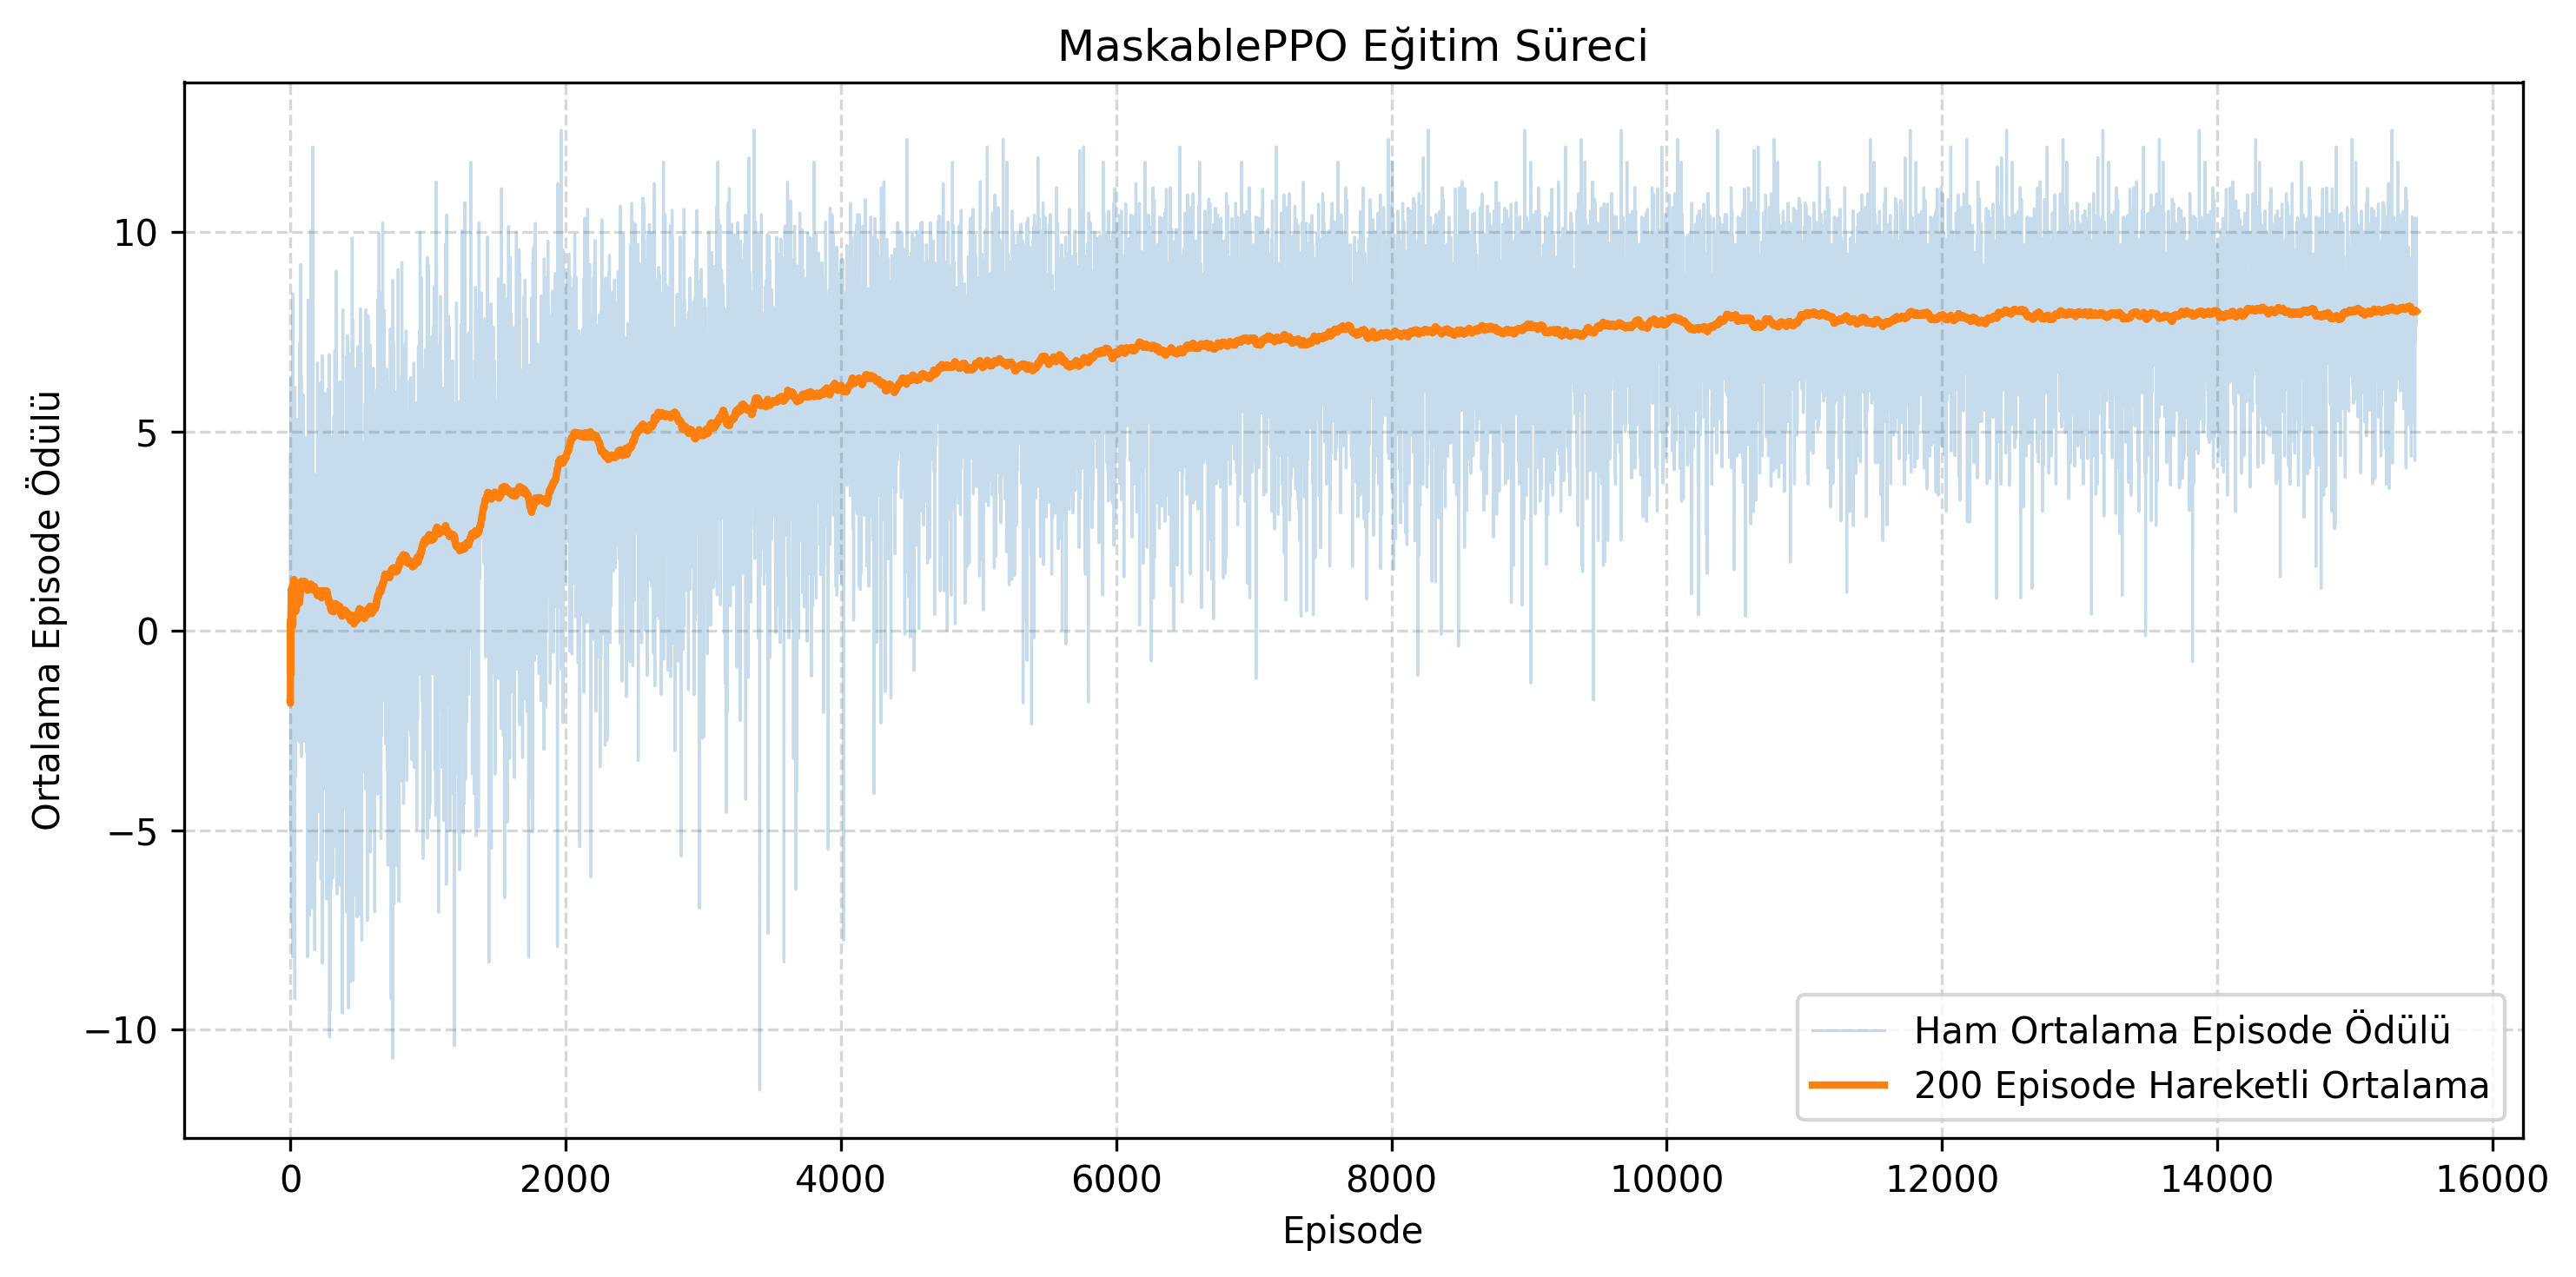

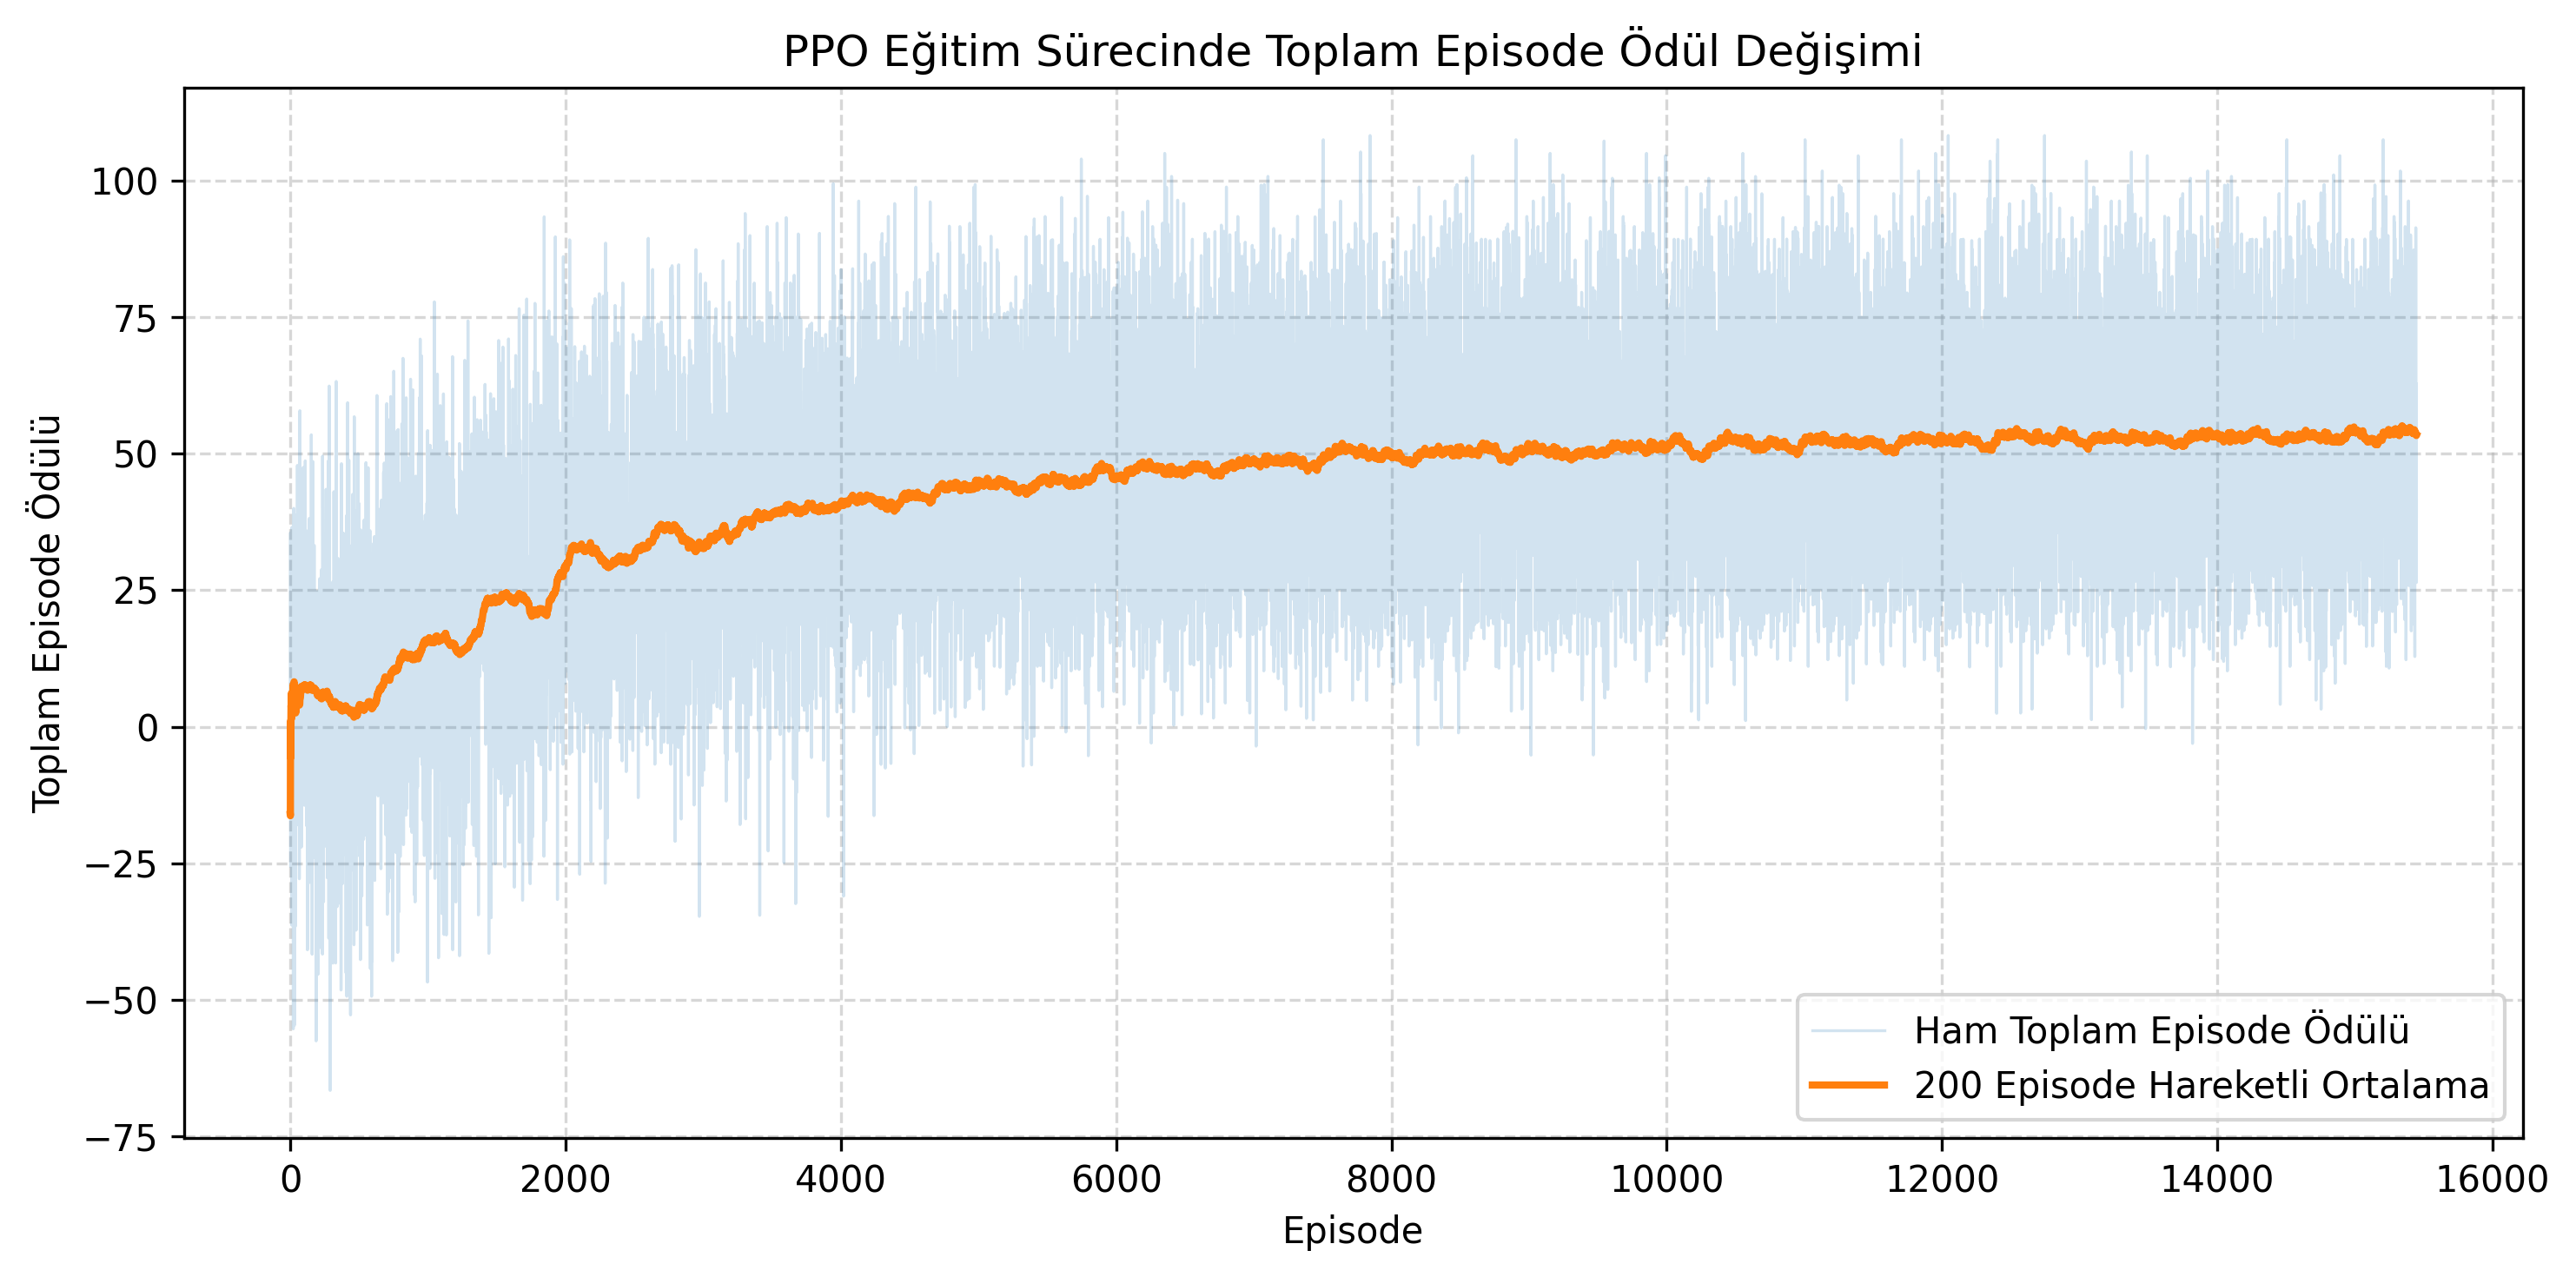

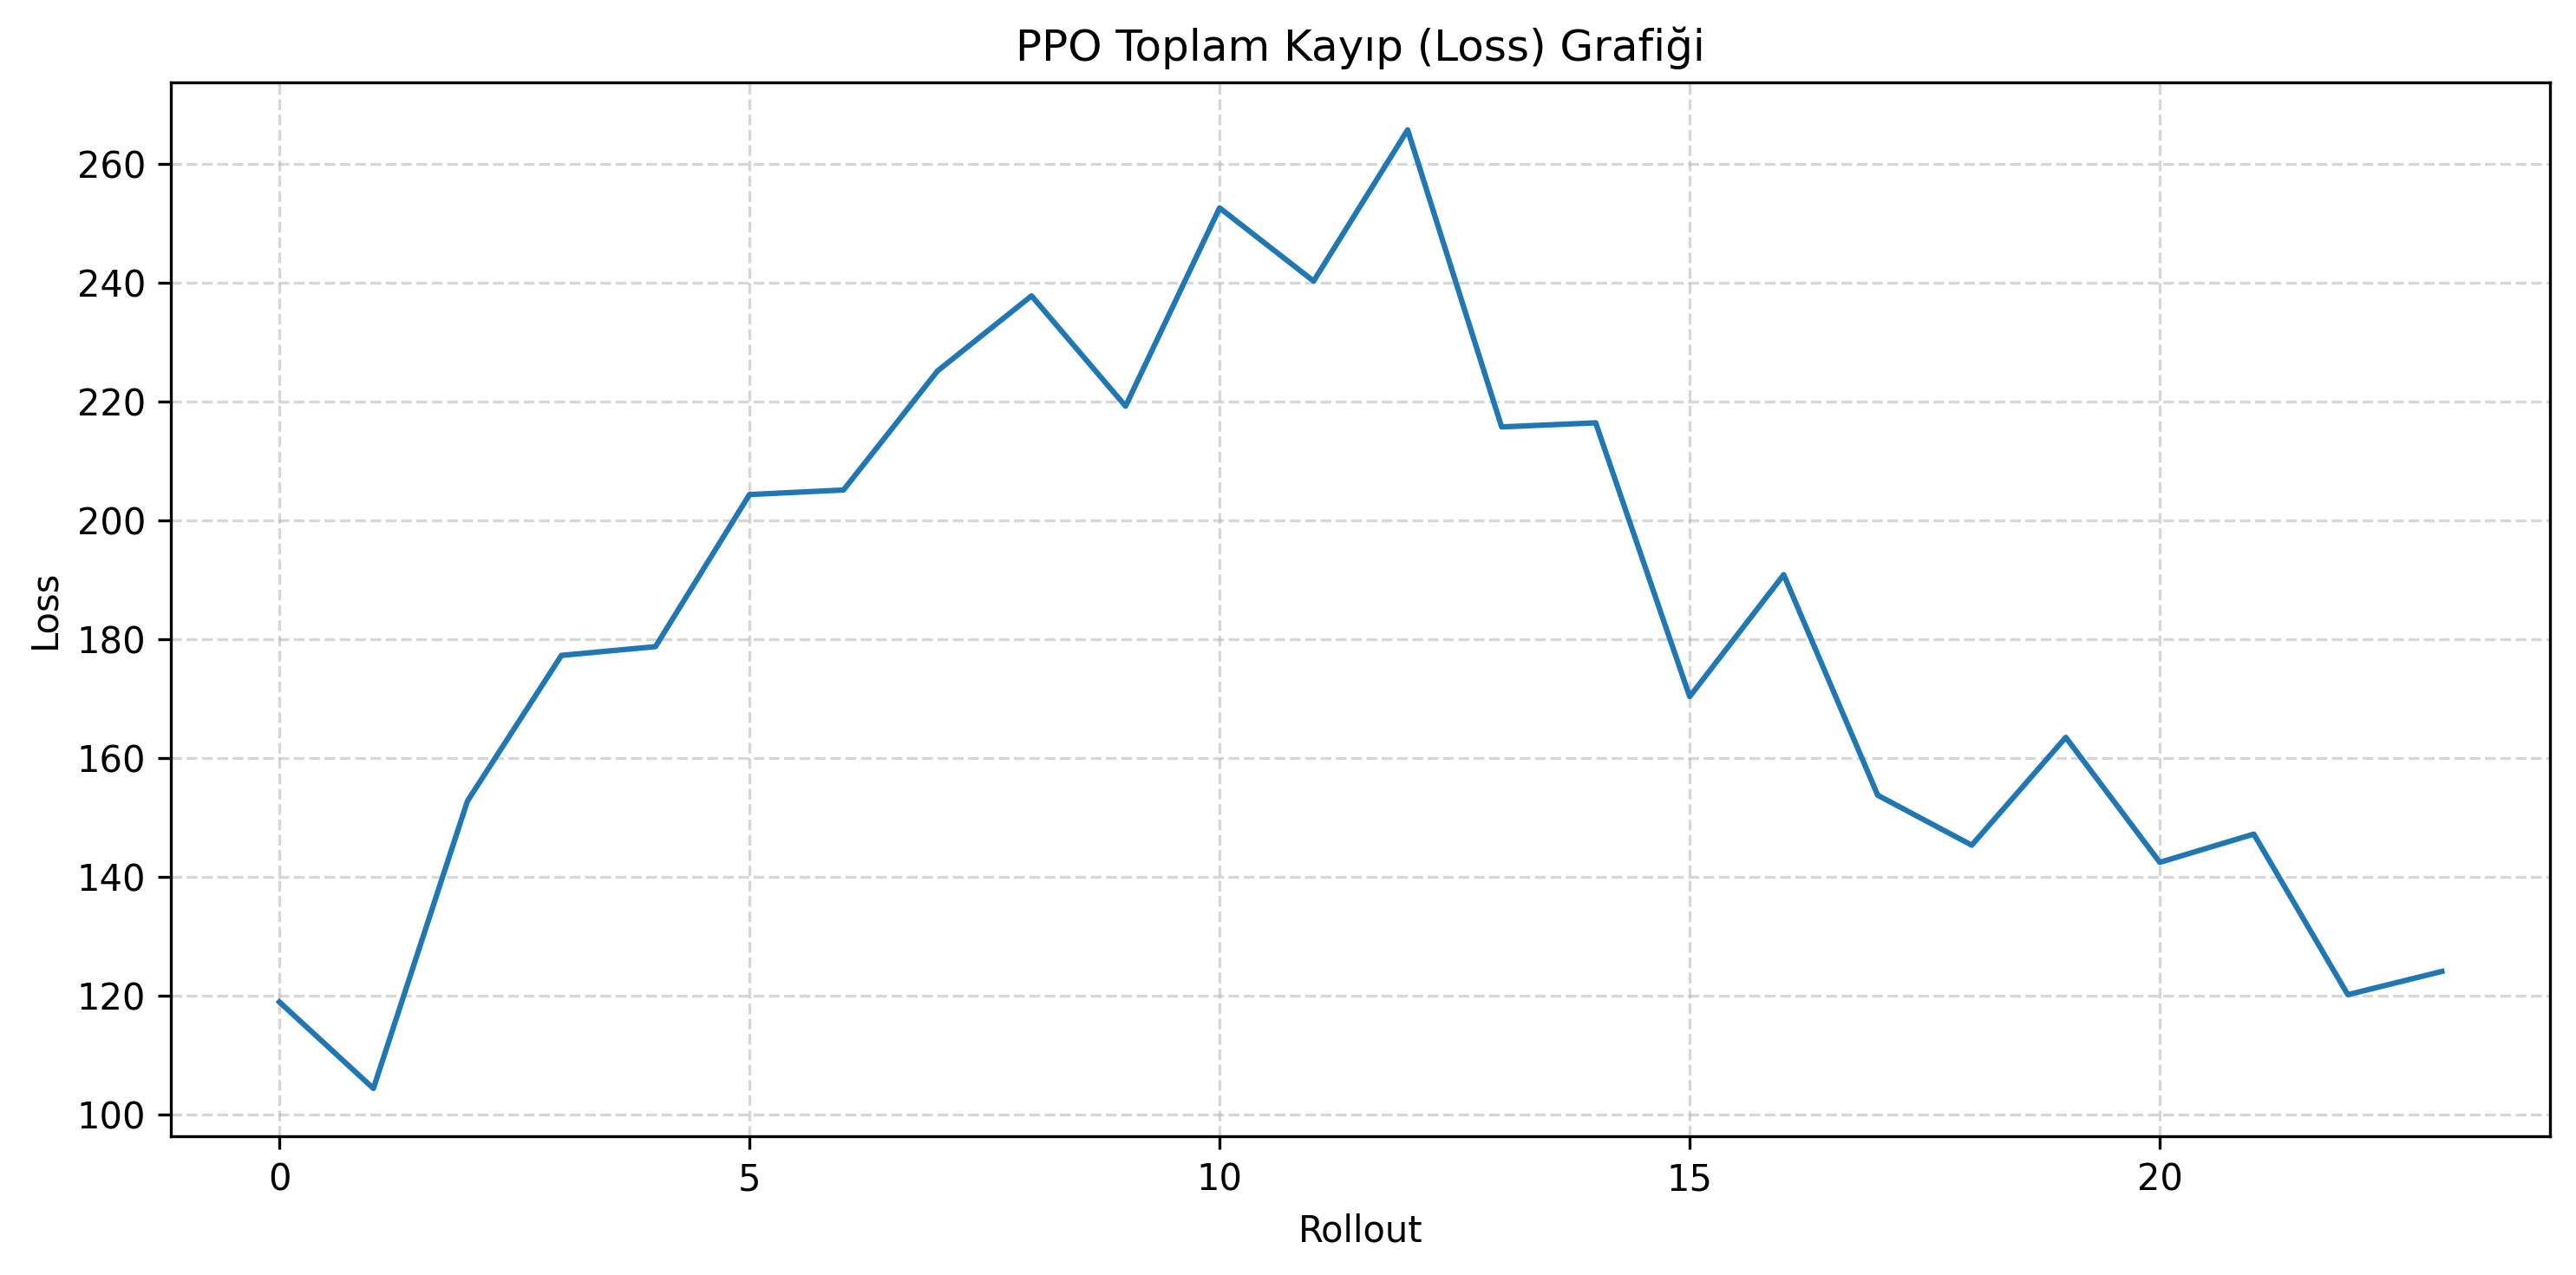

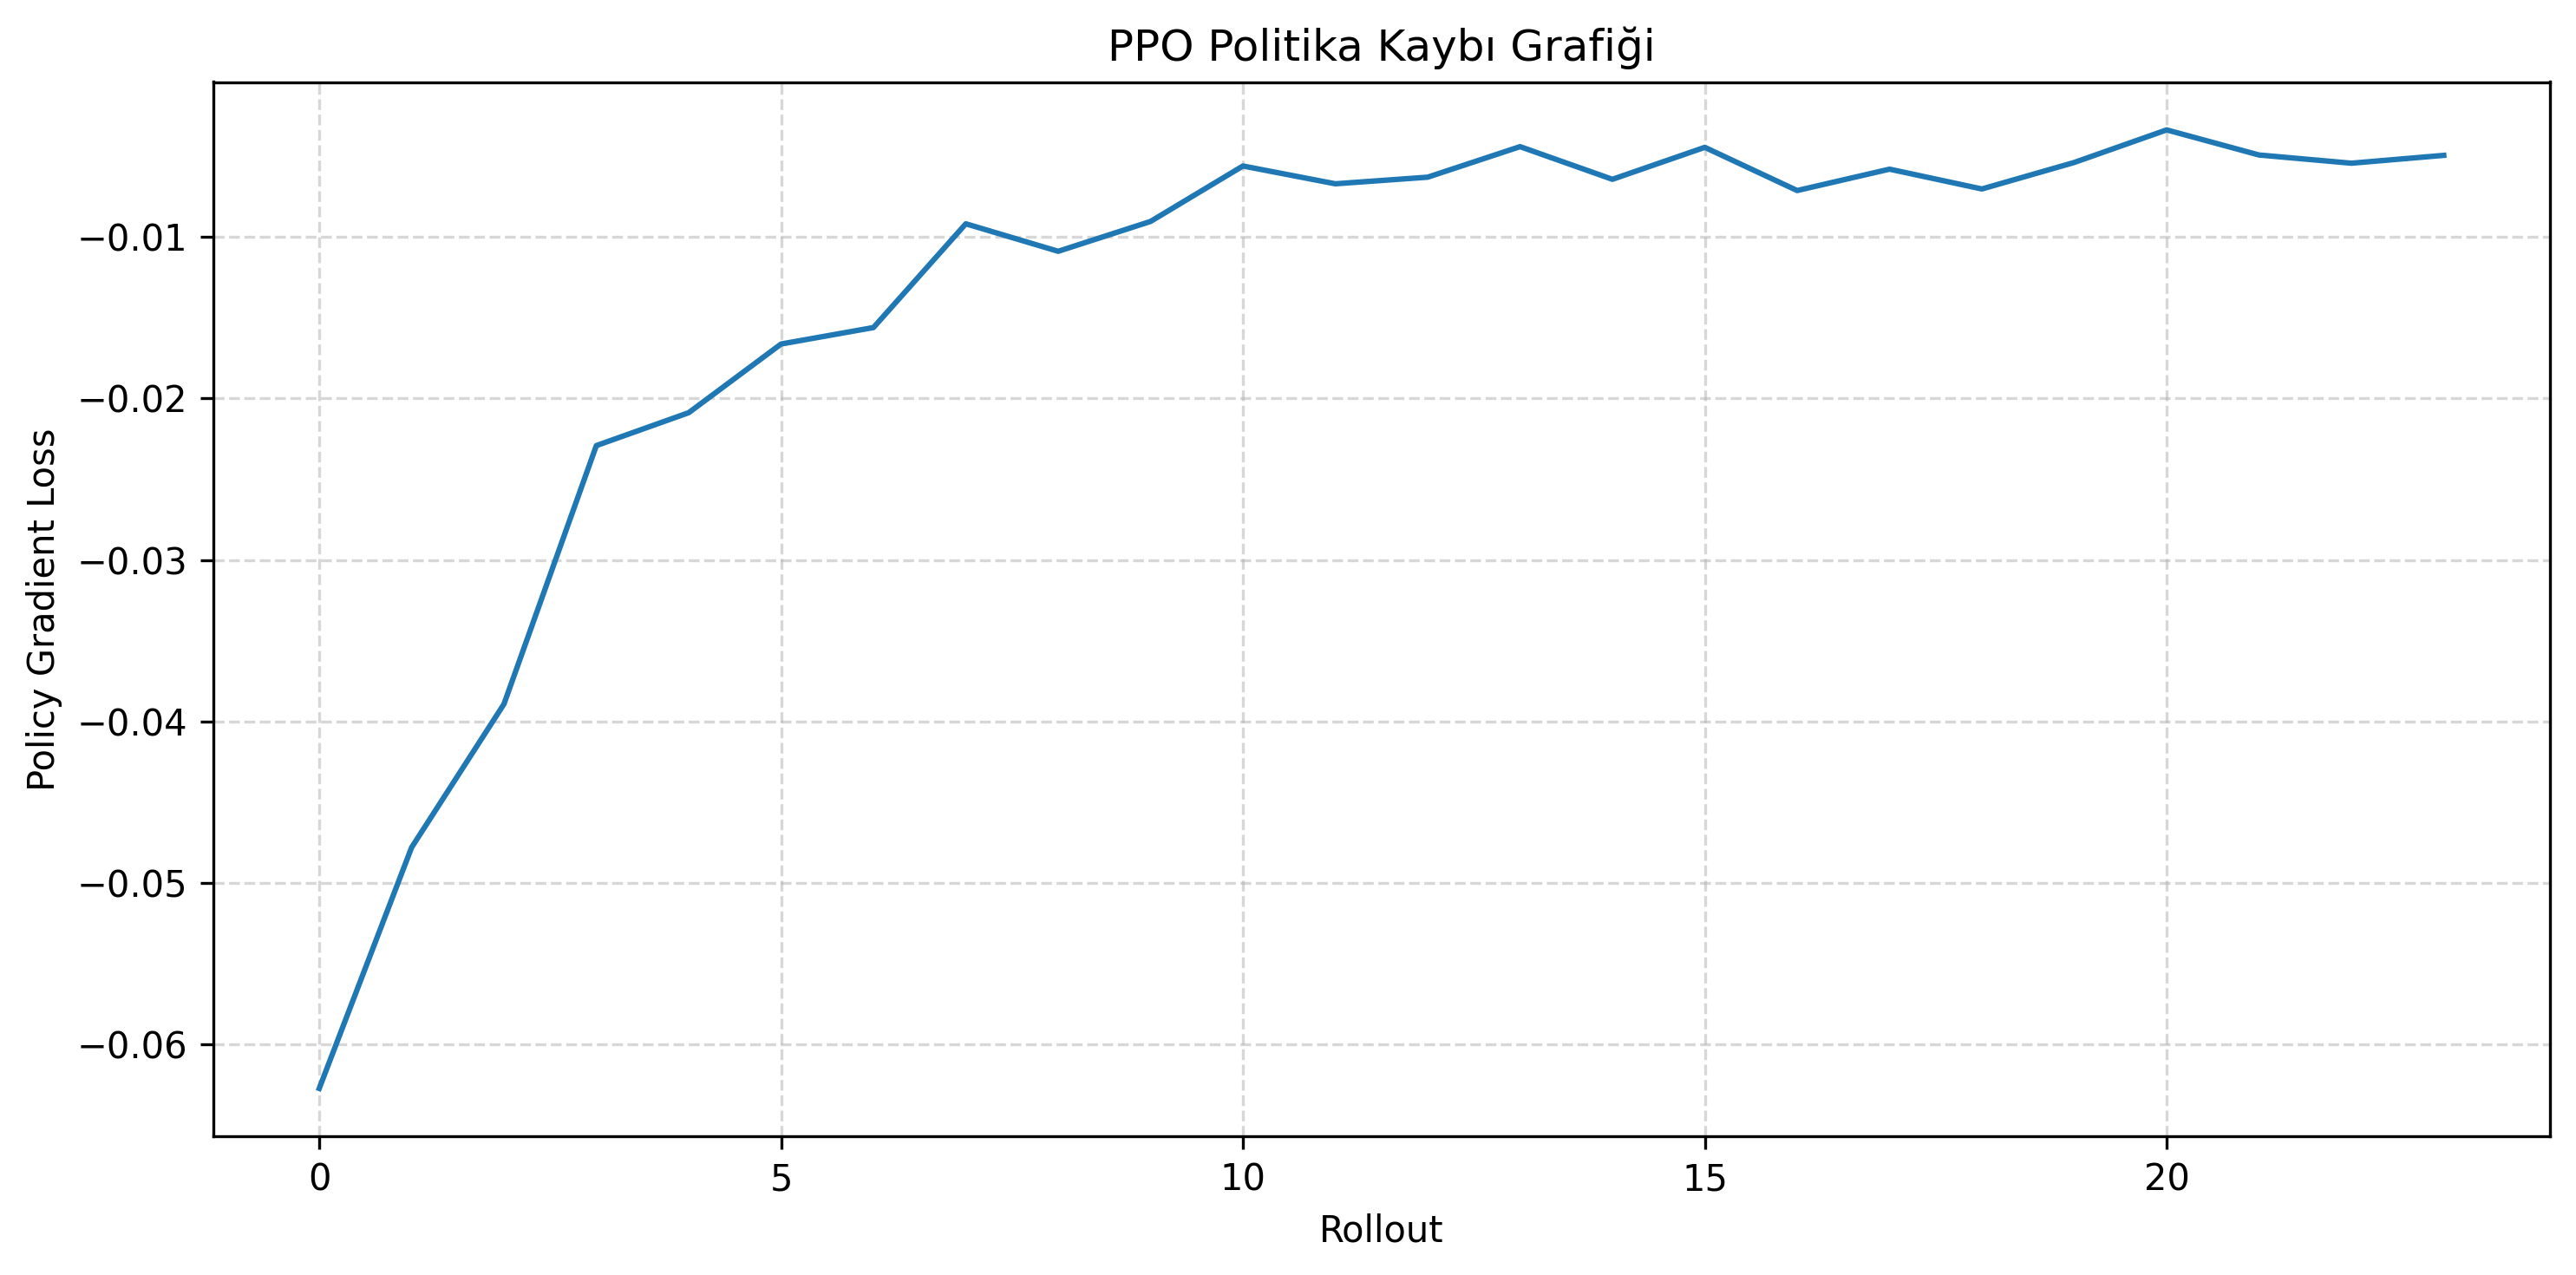

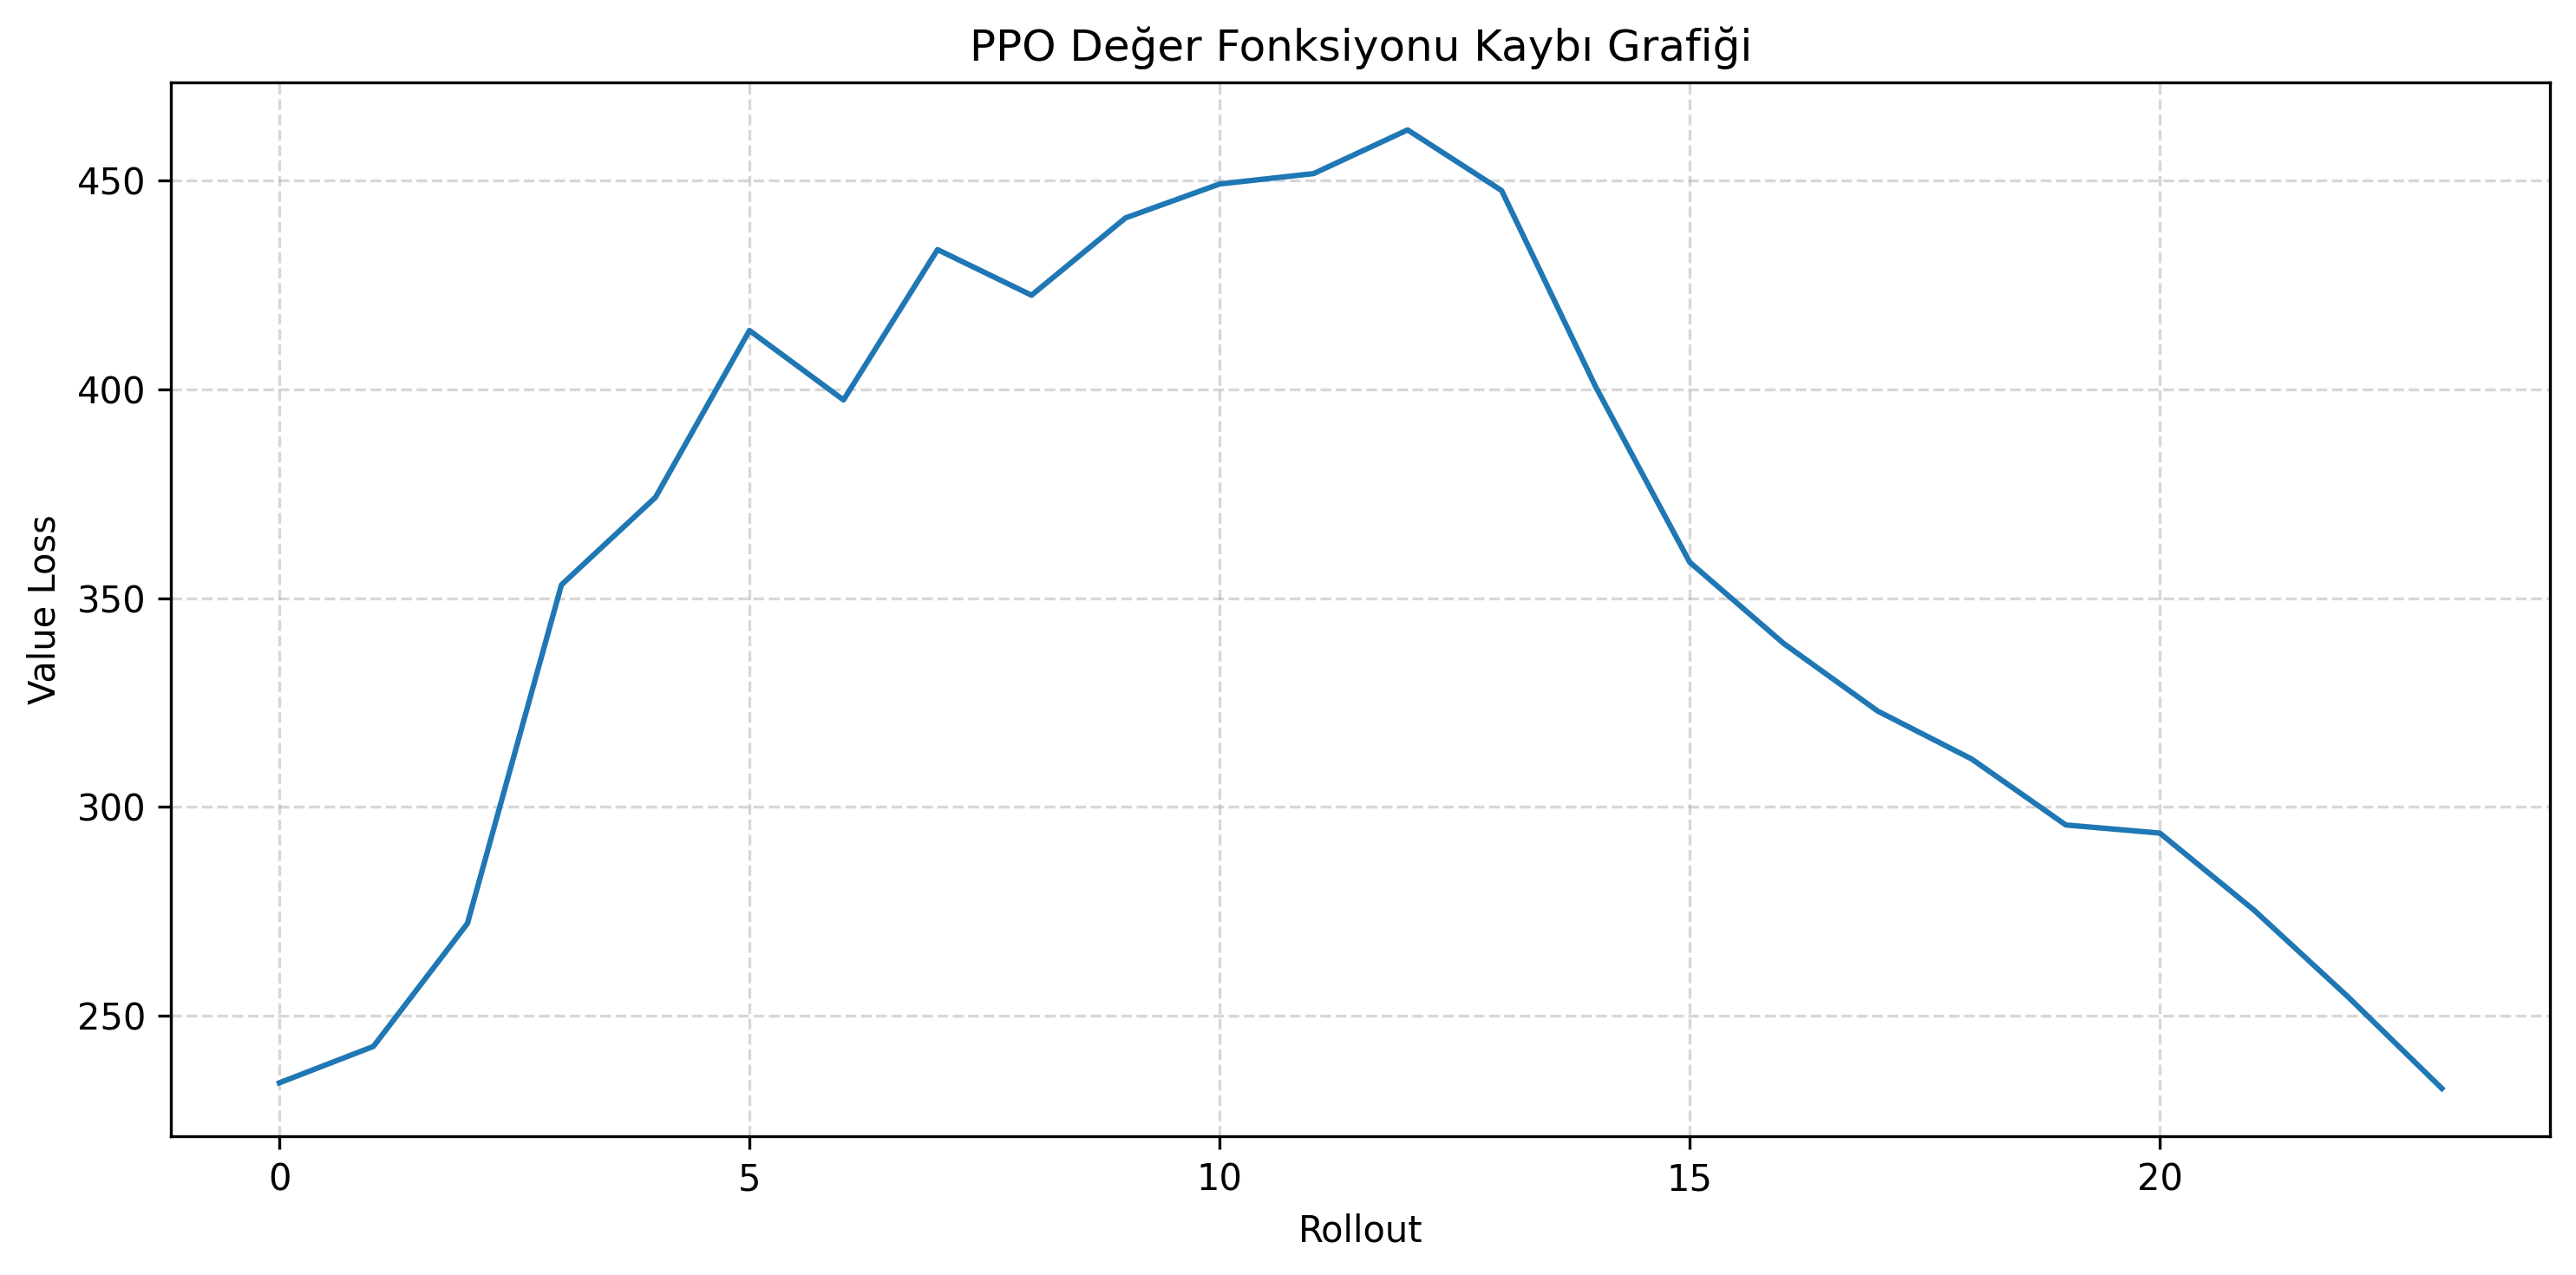

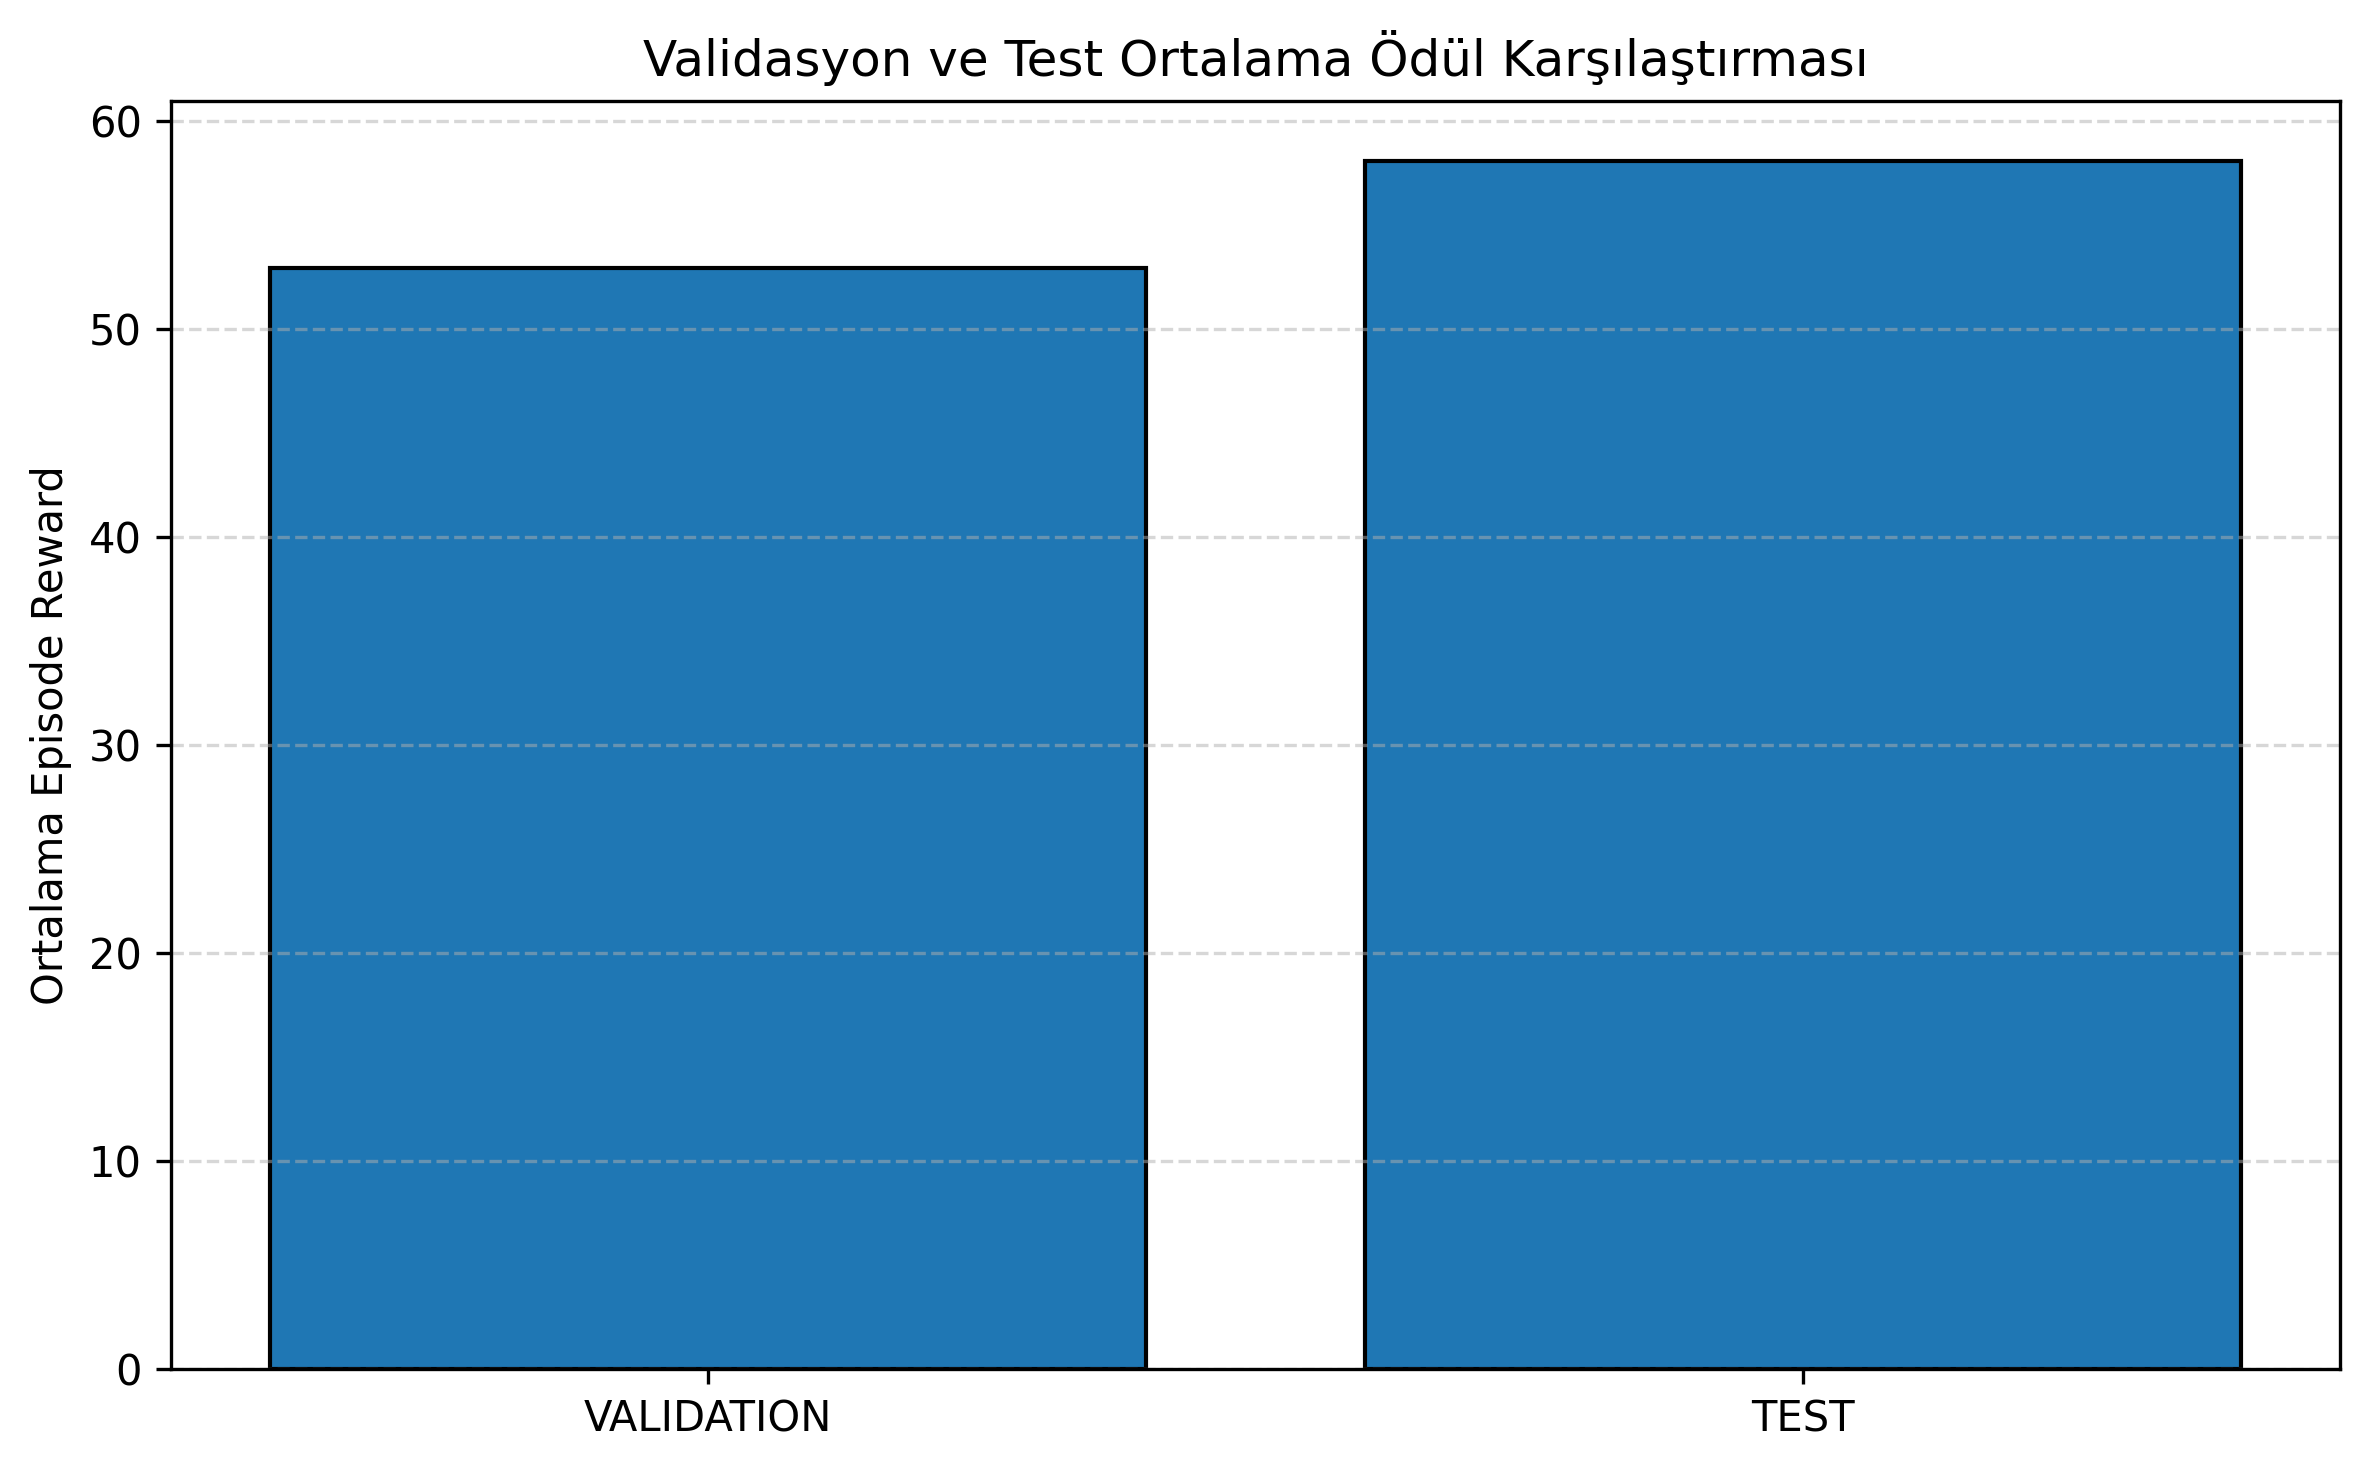

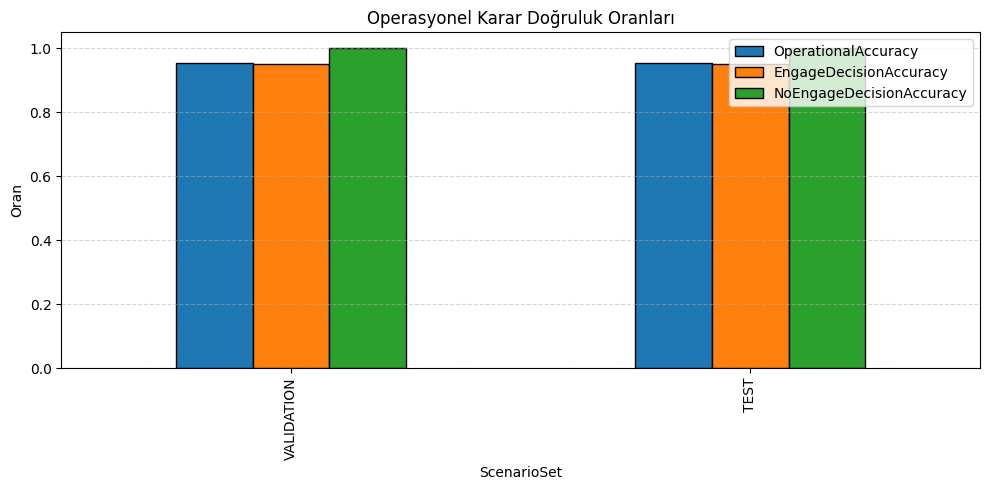

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


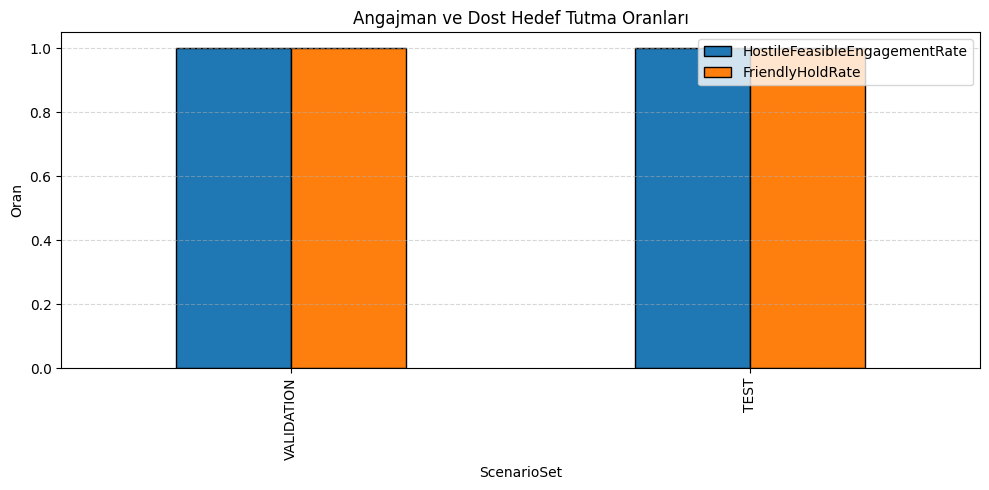

In [49]:

# GRAFİKLER

if len(callback.episode_avg_rewards) > 0:
    reward_series = pd.Series(callback.episode_avg_rewards)


    smooth_window = 200
    reward_smooth = reward_series.rolling(window=smooth_window, min_periods=1).mean()

    plt.figure(figsize=(10, 5), dpi=300)
    plt.plot(reward_series.values, alpha=0.25, linewidth=0.8, label="Ham Ortalama Episode Ödülü")
    plt.plot(reward_smooth.values, linewidth=2.0, label=f"{smooth_window} Episode Hareketli Ortalama")
    plt.xlabel("Episode")
    plt.ylabel("Ortalama Episode Ödülü")
    plt.title("MaskablePPO Eğitim Süreci")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, "training_avg_rewards_smoothed.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()


if len(callback.episode_rewards) > 0:
    raw_reward_series = pd.Series(callback.episode_rewards)
    raw_reward_smooth = raw_reward_series.rolling(window=200, min_periods=1).mean()

    plt.figure(figsize=(10, 5), dpi=300)
    plt.plot(raw_reward_series.values, alpha=0.20, linewidth=0.8, label="Ham Toplam Episode Ödülü")
    plt.plot(raw_reward_smooth.values, linewidth=2.0, label="200 Episode Hareketli Ortalama")
    plt.xlabel("Episode")
    plt.ylabel("Toplam Episode Ödülü")
    plt.title("PPO Eğitim Sürecinde Toplam Episode Ödül Değişimi")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "training_rewards.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

if len(callback.total_loss) > 0:
    plt.figure(figsize=(10, 5), dpi=300)
    plt.plot(callback.total_loss)
    plt.xlabel("Rollout")
    plt.ylabel("Loss")
    plt.title("PPO Toplam Kayıp (Loss) Grafiği")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ppo_total_loss.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

if len(callback.policy_loss) > 0:
    plt.figure(figsize=(10, 5), dpi=300)
    plt.plot(callback.policy_loss)
    plt.xlabel("Rollout")
    plt.ylabel("Policy Gradient Loss")
    plt.title("PPO Politika Kaybı Grafiği")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ppo_policy_loss.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

if len(callback.value_loss) > 0:
    plt.figure(figsize=(10, 5), dpi=300)
    plt.plot(callback.value_loss)
    plt.xlabel("Rollout")
    plt.ylabel("Value Loss")
    plt.title("PPO Değer Fonksiyonu Kaybı Grafiği")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ppo_value_loss.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

plt.figure(figsize=(8, 5), dpi=300)
plt.bar(df_metrics["ScenarioSet"], df_metrics["AvgEpisodeReward"], edgecolor="black")
plt.ylabel("Ortalama Episode Reward")
plt.title("Validasyon ve Test Ortalama Ödül Karşılaştırması")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "val_test_avg_reward_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

rate_df = df_metrics[[
    "ScenarioSet",
    "OperationalAccuracy",
    "EngageDecisionAccuracy",
    "NoEngageDecisionAccuracy"
]].set_index("ScenarioSet")

ax = rate_df.plot(kind="bar", figsize=(10, 5), edgecolor="black")
ax.set_ylabel("Oran")
ax.set_title("Operasyonel Karar Doğruluk Oranları")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "operational_accuracy_rates.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

rate_df_2 = df_metrics[[
    "ScenarioSet",
    "HostileFeasibleEngagementRate",
    "FriendlyHoldRate"
]].set_index("ScenarioSet")

ax = rate_df_2.plot(kind="bar", figsize=(10, 5), edgecolor="black")
ax.set_ylabel("Oran")
ax.set_title("Angajman ve Dost Hedef Tutma Oranları")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "operational_rates.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()



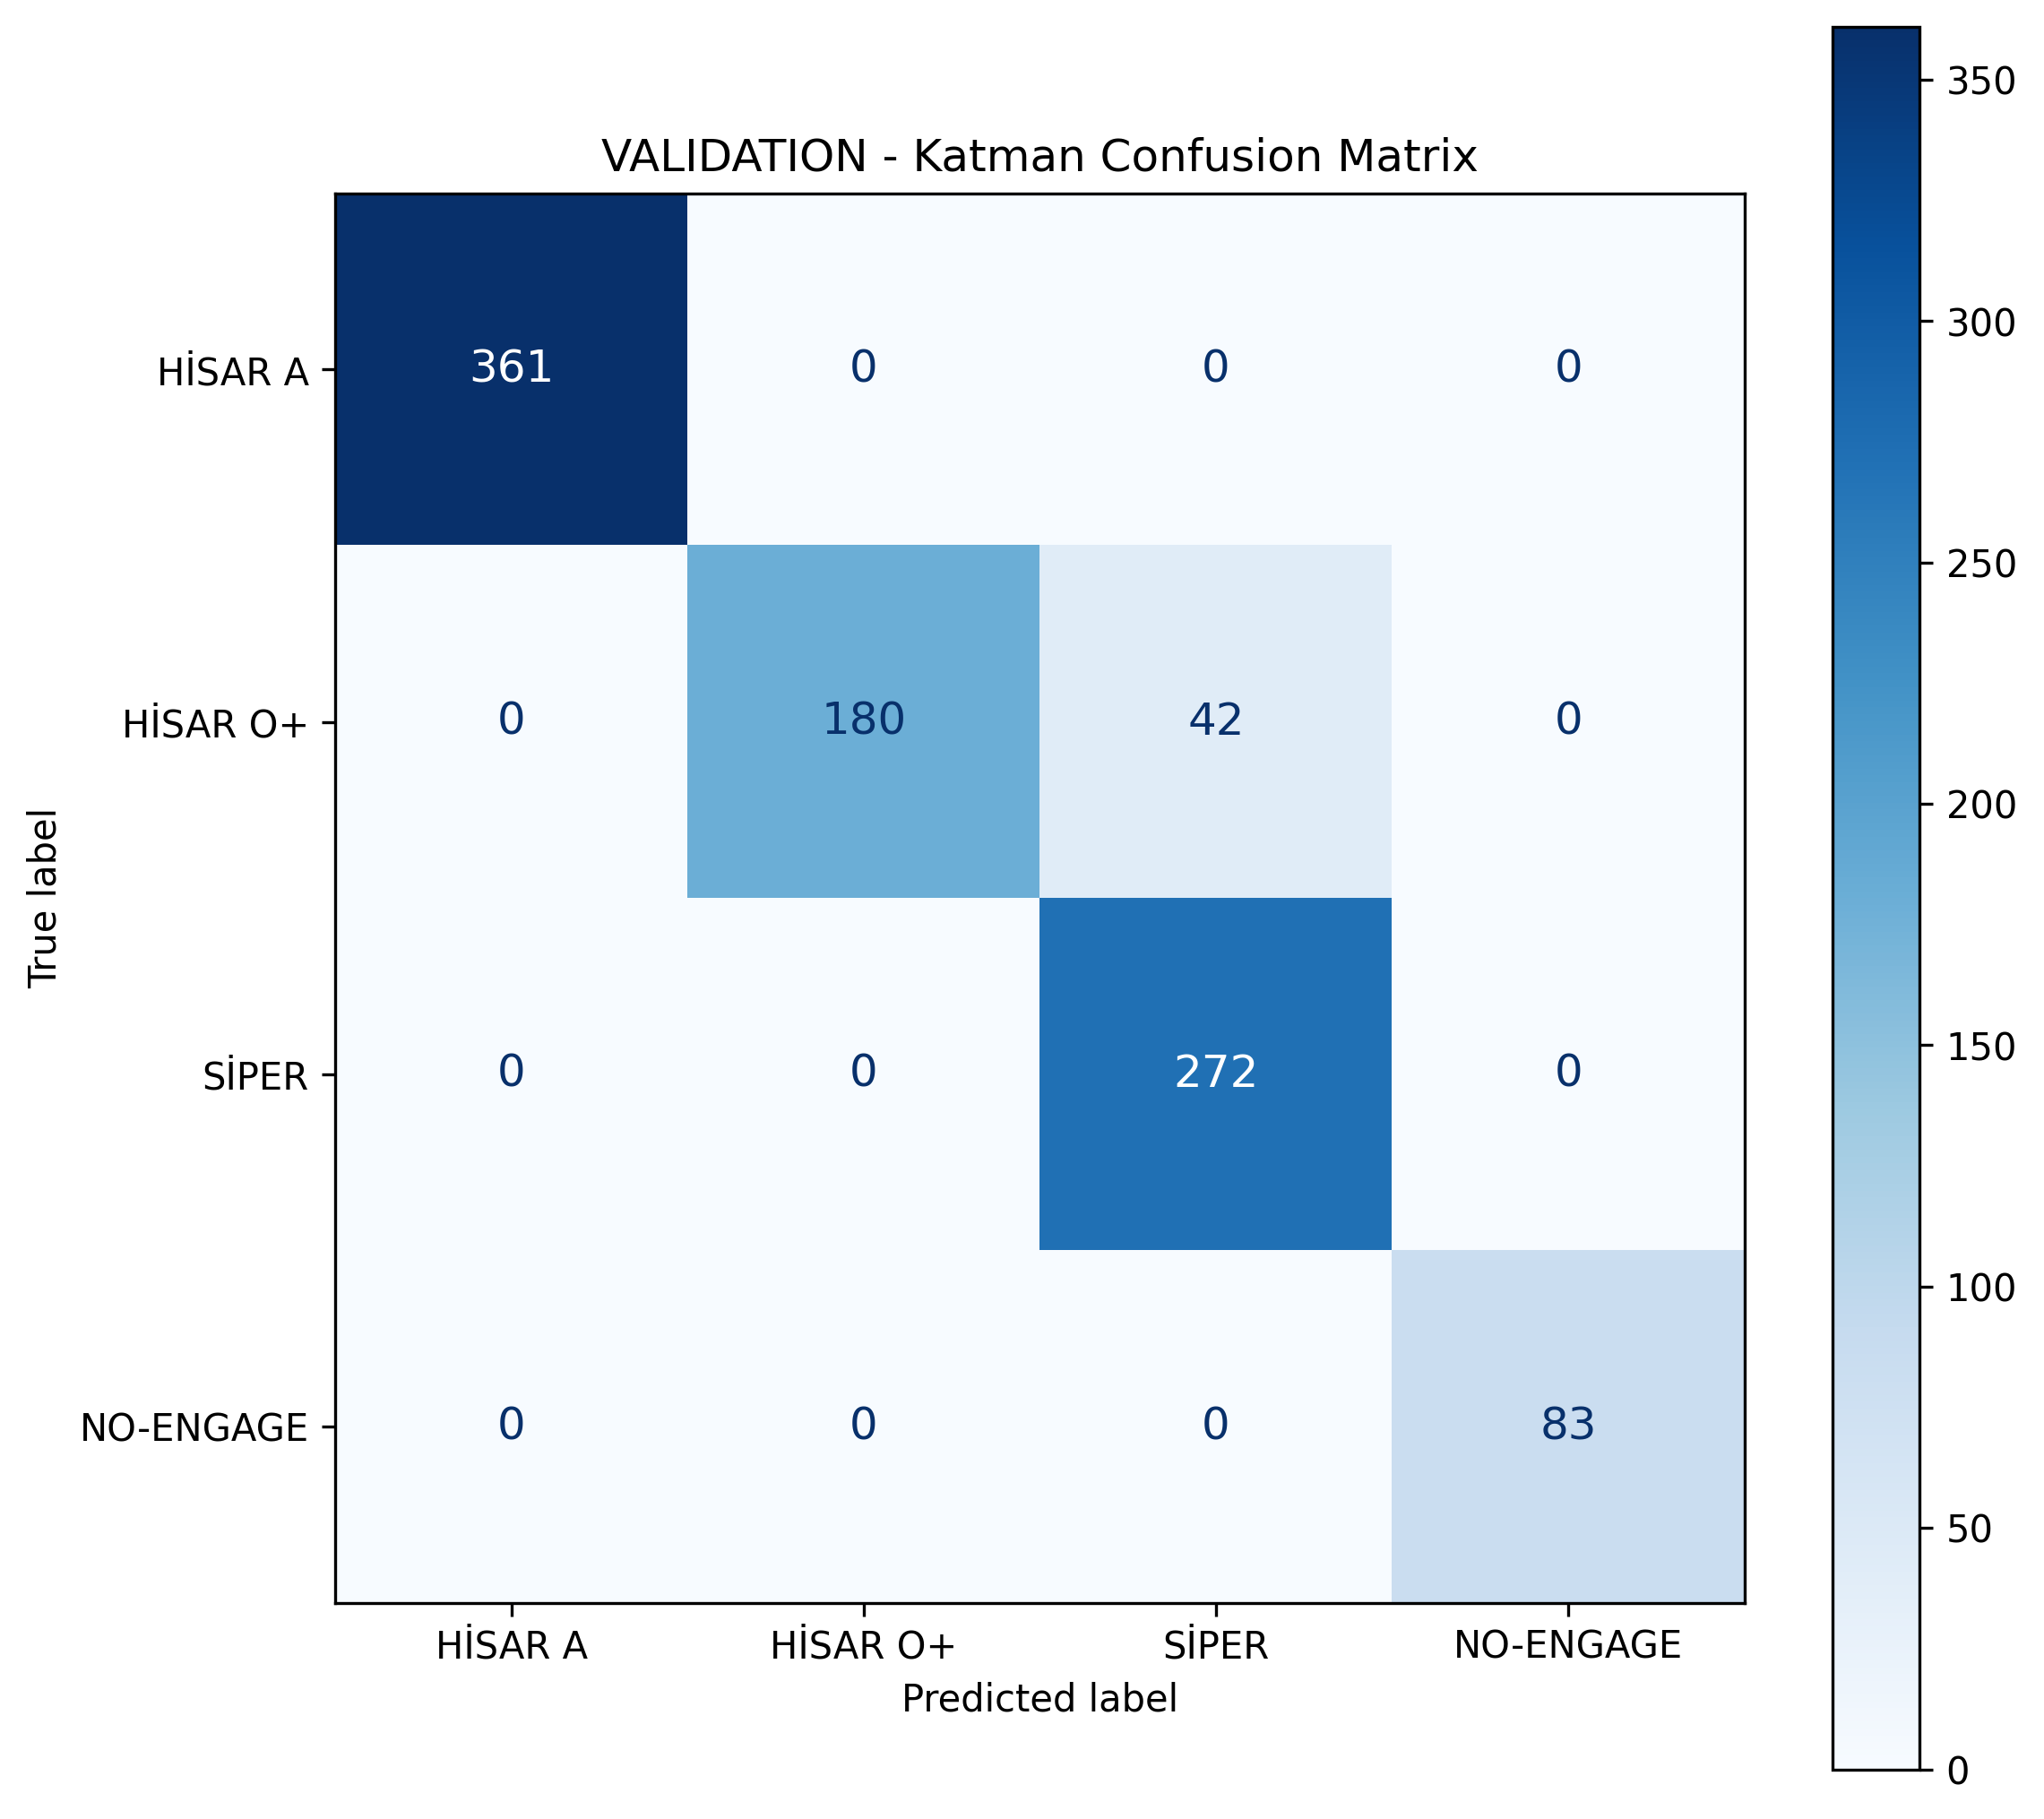

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


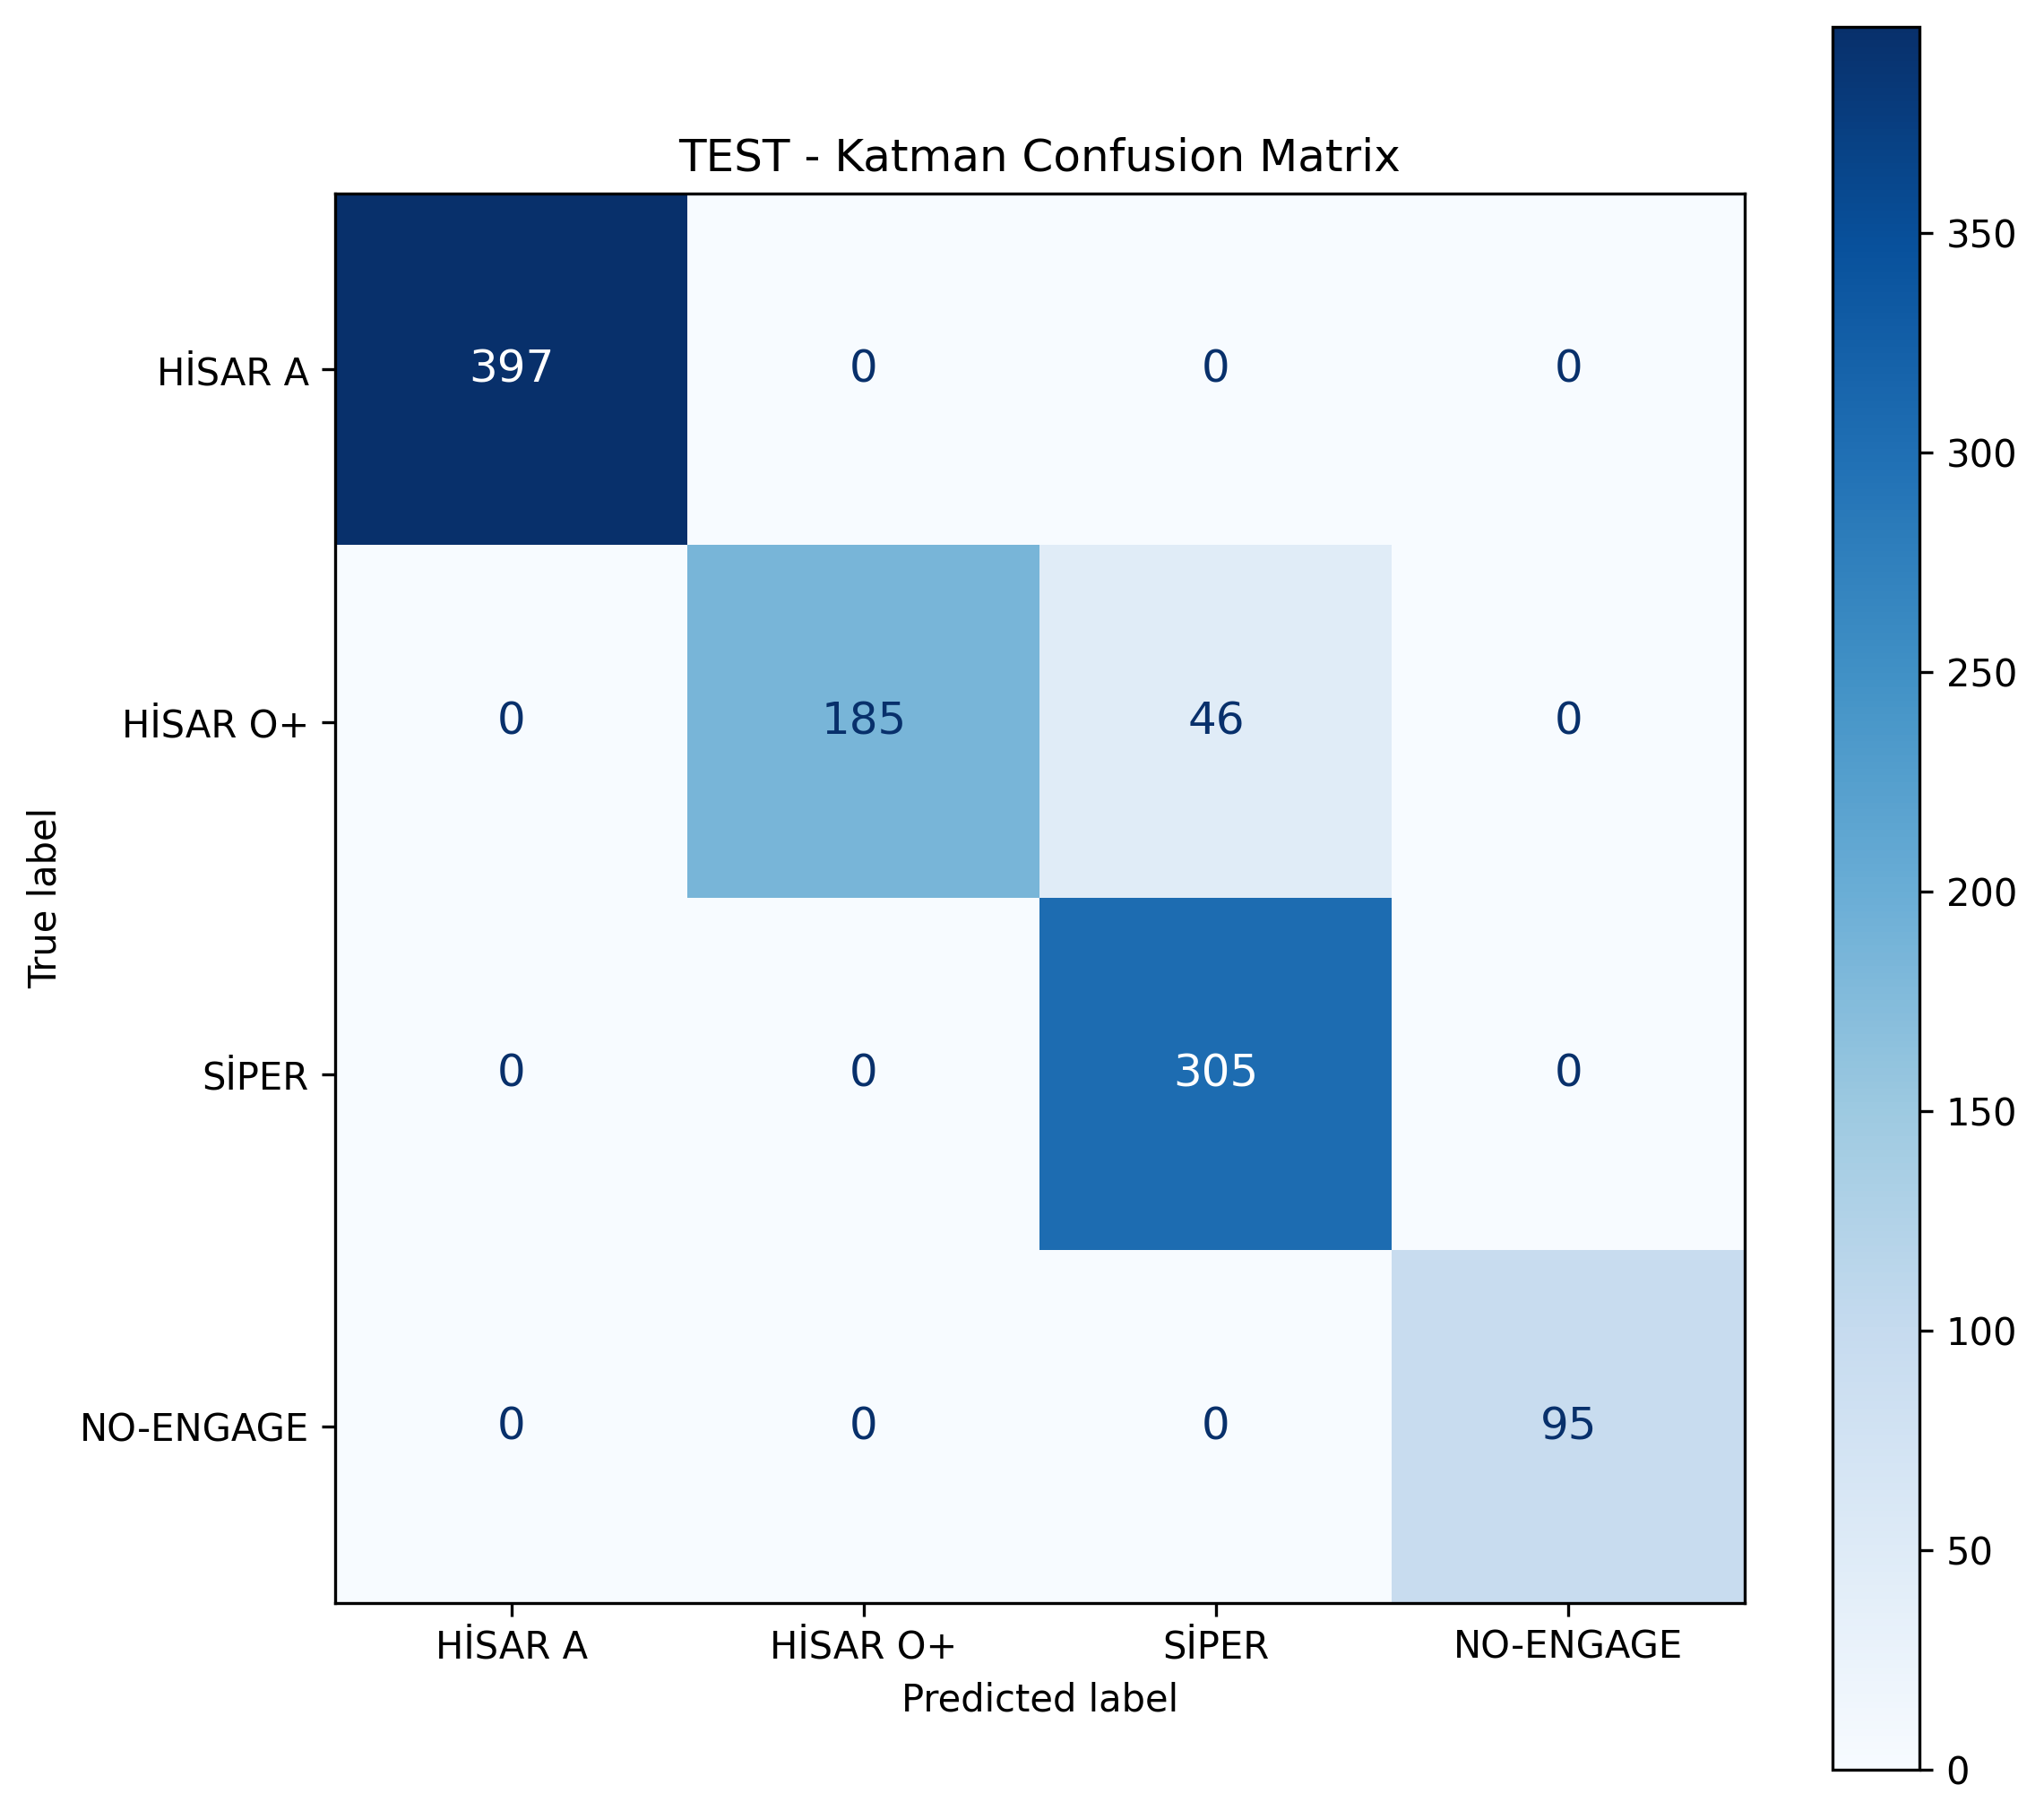

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [50]:


#  CONFUSION MATRIX

def plot_confusion_matrix(df_results, title, save_path):
    labels = ["HİSAR A", "HİSAR O+", "SİPER", "NO-ENGAGE"]
    label_to_idx = {label: idx for idx, label in enumerate(labels)}

    cm = np.zeros((len(labels), len(labels)), dtype=int)

    for _, row in df_results.iterrows():
        true_label = row["ExpectedAction"]
        pred_label = row["ChosenAction"]

        if true_label not in label_to_idx:
            true_label = "NO-ENGAGE"
        if pred_label not in label_to_idx:
            pred_label = "NO-ENGAGE"

        cm[label_to_idx[true_label], label_to_idx[pred_label]] += 1

    plt.figure(figsize=(8, 7), dpi=300)
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=0)
    plt.yticks(tick_marks, labels)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "#08306b",
                fontsize=12
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

plot_confusion_matrix(
    df_val_results,
    "VALIDATION - Katman Confusion Matrix",
    os.path.join(OUTPUT_DIR, "validation_confusion_matrix.png")
)

plot_confusion_matrix(
    df_test_results,
    "TEST - Katman Confusion Matrix",
    os.path.join(OUTPUT_DIR, "test_confusion_matrix.png")
)




In [51]:

#  ÖRNEK TEST SENARYOSU

# ÖRNEK TEST SENARYOSU

print("\n=== ÖRNEK TEST SENARYOSU ===")

example_env = MultiTargetTEWAEnv(
    [test_scenarios[0]],
    max_targets=MAX_TARGETS
)

example_wrapped = ActionMasker(example_env, mask_fn)

obs, info = example_wrapped.reset()
done = False
example_total_reward = 0.0

example_initial_info = []

for i in range(example_env.num_targets):
    tgt0 = example_env.df_targets.iloc[i].copy()

    feasible_systems_initial = get_feasible_systems_initial(
        example_env,
        tgt0
    )

    expected_action, feasible_initial_code = get_expected_action(
        example_env,
        tgt0
    )

    example_initial_info.append({
        "FeasibleSystemsInitial": feasible_systems_initial,
        "ExpectedAction": expected_action,
        "FeasibleInitial": feasible_initial_code
    })

while not done:
    action, _ = model.predict(
        obs,
        deterministic=True,
        action_masks=get_action_masks(example_wrapped)
    )

    obs, reward, done, truncated, step_info = example_wrapped.step(action)

    example_total_reward += reward

print(
    example_env.df_targets[
        [
            "Name",
            "RewardSignal",
            "TargetCostScore",
            "Distance_km",
            "Altitude_m",
            "ECMScore",
            "IFF",
            "Speed_kmh",
            "TTI_sec",
            "TTI_score"
        ]
    ]
)

example_rows = []

system_names_example = [
    s["name"] for s in example_env.systems
]

for i in range(example_env.num_targets):
    chosen_action = example_env.decisions[i]
    expected_action = example_initial_info[i]["ExpectedAction"]

    operational_correct = is_operationally_correct(
        chosen_action,
        expected_action
    )

    if chosen_action in system_names_example:
        chosen_sys_idx = system_names_example.index(chosen_action)

        p_kill_estimate = example_env._compute_pkill(
            example_env.df_targets.iloc[i],
            chosen_sys_idx
        )
    else:
        p_kill_estimate = 0.0

    example_rows.append({
        "TargetName": example_env.df_targets.iloc[i]["Name"],
        "RewardSignal": float(example_env.df_targets.iloc[i]["RewardSignal"]),
        "TargetCostScore": float(example_env.df_targets.iloc[i]["TargetCostScore"]),
        "FeasibleInitial": example_initial_info[i]["FeasibleInitial"],
        "ExpectedAction": expected_action,
        "ChosenAction": chosen_action,
        "PkillEstimate": p_kill_estimate,
        "OperationalCorrect": operational_correct
    })

df_example = pd.DataFrame(example_rows)

print("\n=== ÖRNEK SENARYO KARARLARI ===")
print(df_example)

with open(
    os.path.join(OUTPUT_DIR, "example_test_scenario_report.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write("EXAMPLE TEST SCENARIO REPORT - TARGET COST SCORE INCLUDED\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Toplam episode reward: {example_total_reward:.4f}\n\n")

    f.write("HEDEF TABLOSU\n")
    f.write("-" * 80 + "\n")
    f.write(example_env.df_targets.to_string(index=False))

    f.write("\n\nKARARLAR\n")
    f.write("-" * 80 + "\n")
    f.write(df_example.to_string(index=False))


# SONUÇ DOSYA LİSTESİ

print("\nKaydedilen dosyalar:")

for root, dirs, files in os.walk(OUTPUT_DIR):
    for file in files:
        print("-", os.path.join(root, file))


=== ÖRNEK TEST SENARYOSU ===
                   Name  RewardSignal  TargetCostScore  Distance_km  \
0         Su-27 Flanker      0.951432         0.016198        56.17   
1  F-16 Fighting Falcon      0.743712         0.032873         7.91   
2            B-2 Spirit      0.527206         1.000000        12.78   

   Altitude_m  ECMScore  IFF  Speed_kmh    TTI_sec  TTI_score  
0     3766.01      1.00    0    2630.33  76.877046   0.000000  
1     5942.82      0.75    2    2282.55  12.475521   1.000000  
2     6785.32      0.75    2     912.40  50.425252   0.410732  

=== ÖRNEK SENARYO KARARLARI ===
             TargetName  RewardSignal  TargetCostScore  FeasibleInitial  \
0         Su-27 Flanker      0.951432         0.016198                1   
1  F-16 Fighting Falcon      0.743712         0.032873                2   
2            B-2 Spirit      0.527206         1.000000                1   

  ExpectedAction ChosenAction  PkillEstimate  OperationalCorrect  
0          SİPER        SİPE

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



=== SHAP SURROGATE VERİ BOYUTLARI ===
X_shap shape: (800, 21)
y_shap shape: (800,)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== SURROGATE MODEL PERFORMANSI ===
R2  : 0.9954
MAE : 0.1604


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



=== GLOBAL SHAP İLK 20 ===
                            Feature  MeanAbsSHAP
0                      RewardSignal     1.851815
1                      DistanceNorm     0.947850
2                          TTIScore     0.654314
3                   System_MaxRange     0.653606
4                System_MaxAltitude     0.611595
5                     System_BasePk     0.564310
6                   System_CostNorm     0.561191
7              System_ECMResistance     0.508808
8                 FeasibleCountNorm     0.214774
9                       MaxAltitude     0.137702
10                  System_MinRange     0.079384
11                         MaxSpeed     0.052109
12  System_RemainingEngagementRatio     0.025920
13     System_RemainingMissileRatio     0.024699
14                  TargetCostScore     0.024167
15                              RCS     0.023961
16                     AltitudeNorm     0.016561
17                         MaxRange     0.014420
18                    ManeuverScore     0

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


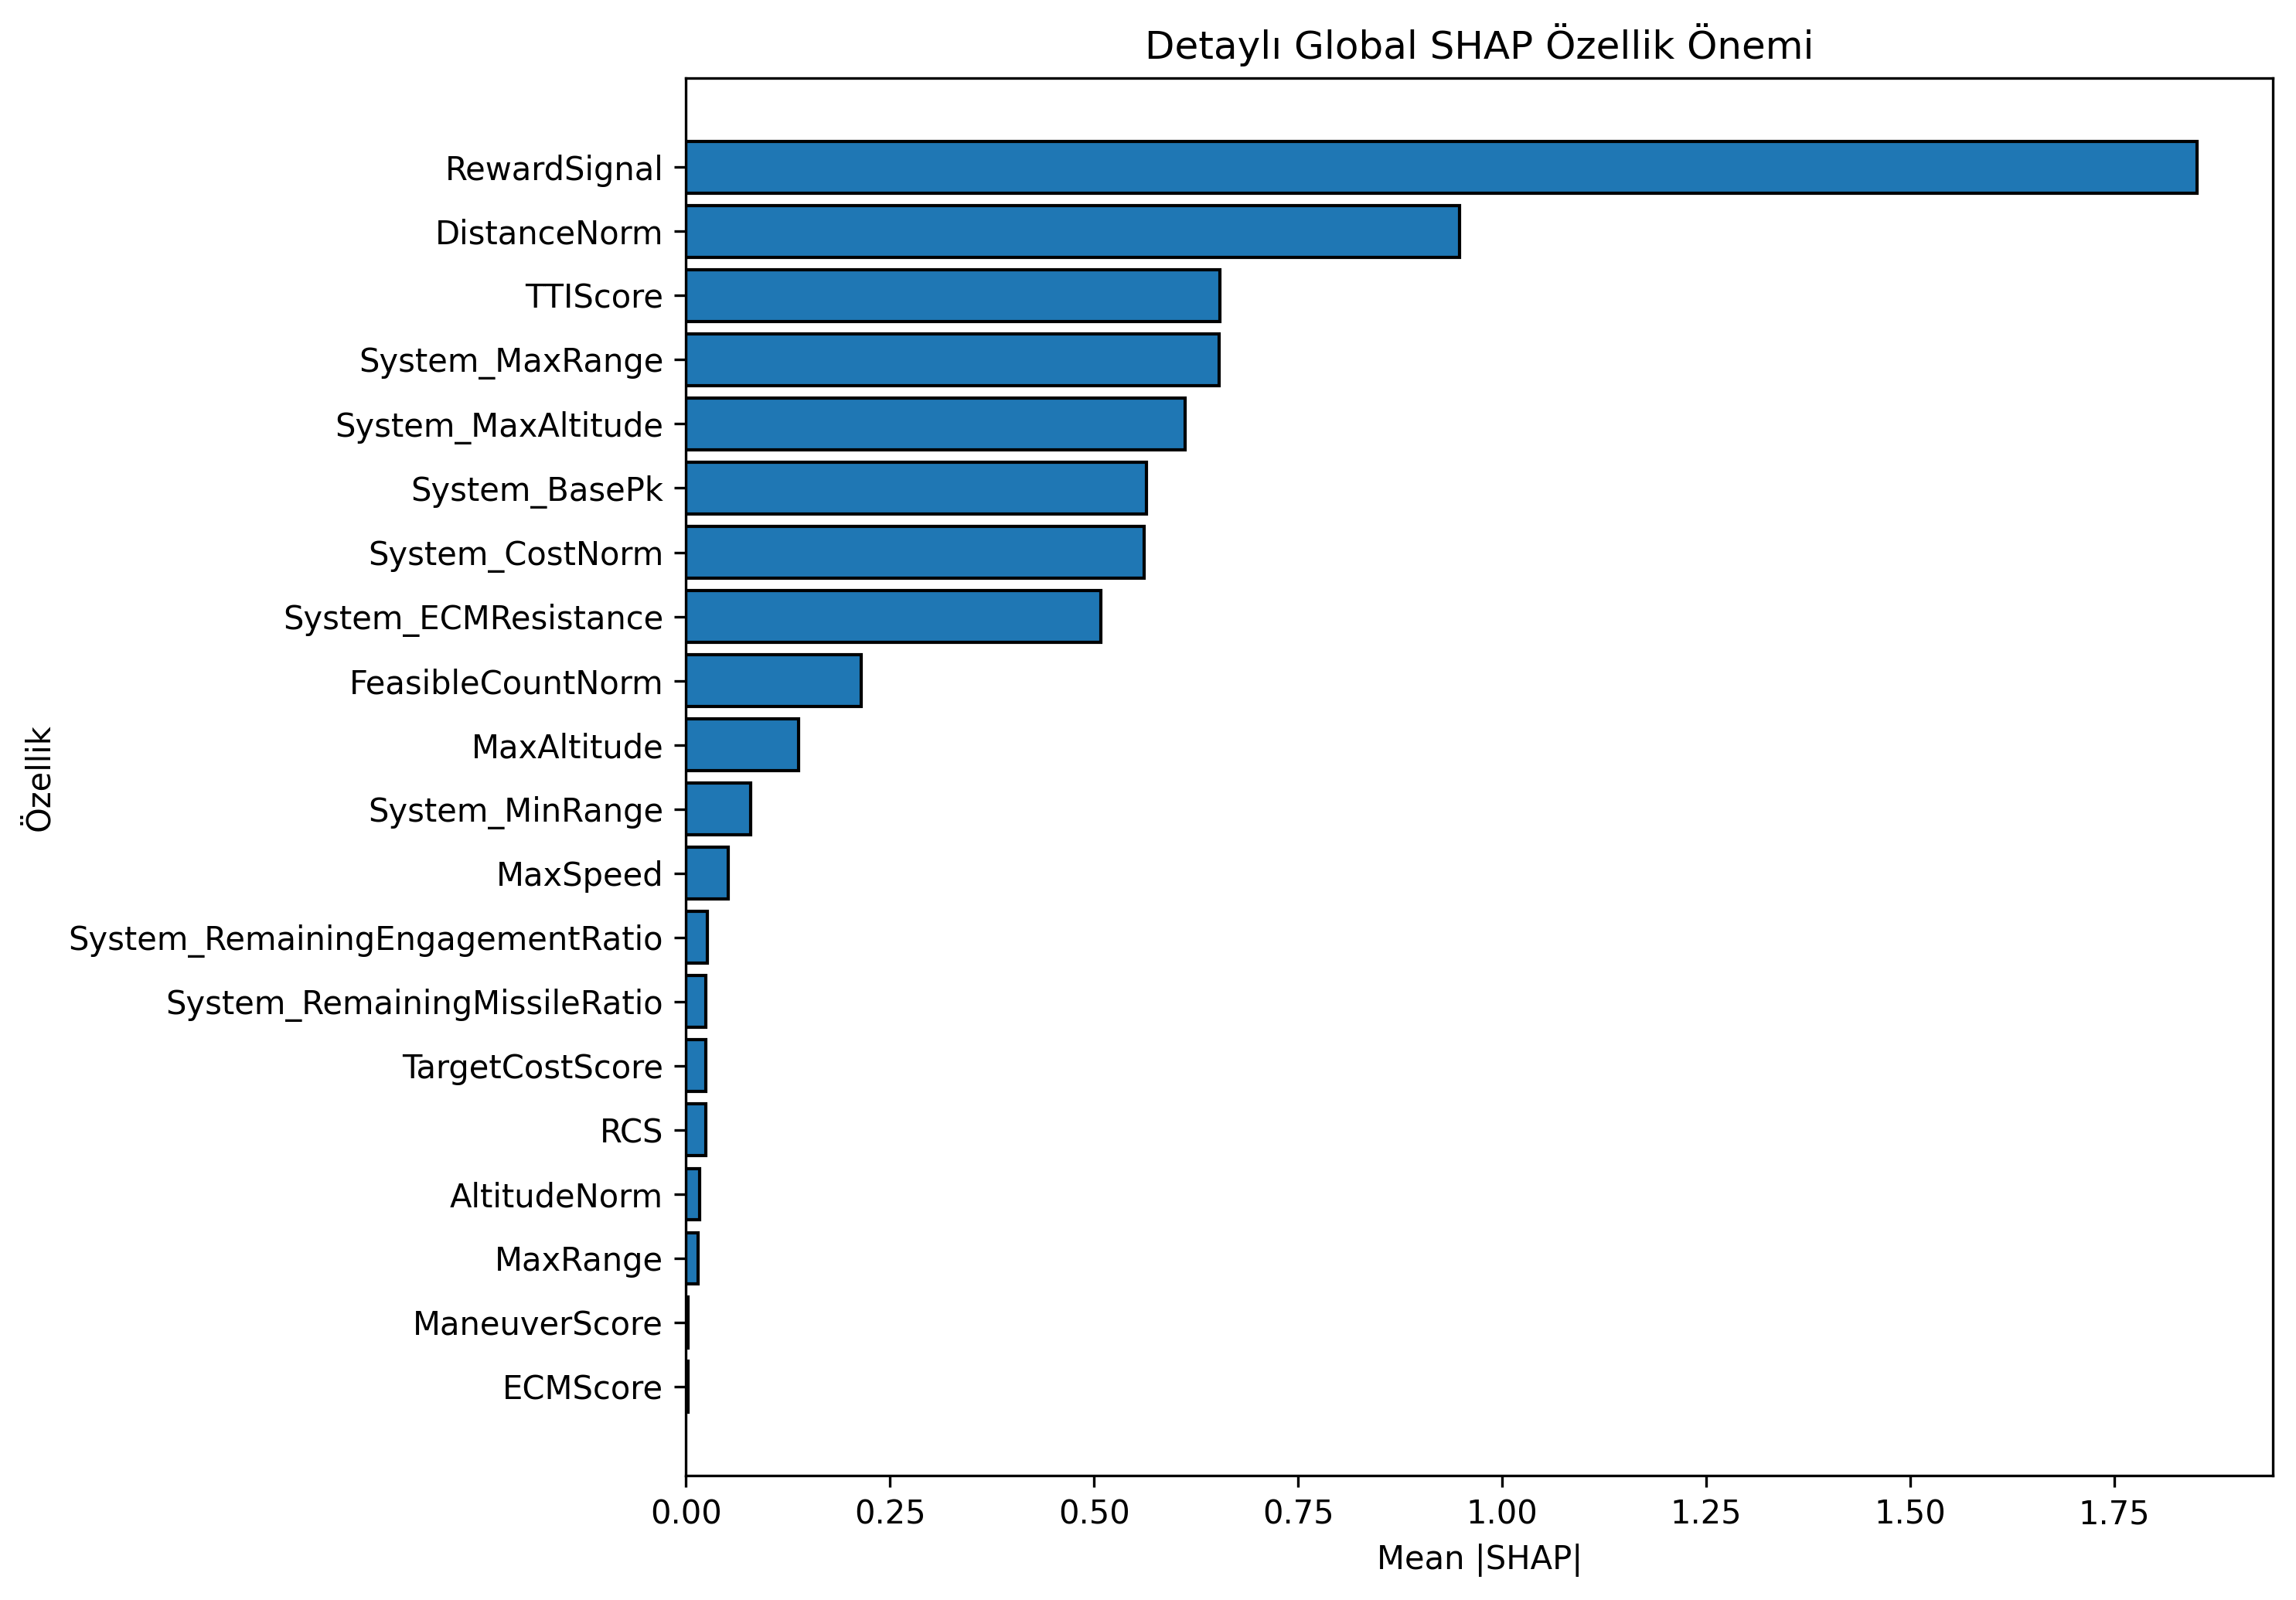

/tmp/ipykernel_1814/3868631170.py:401: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


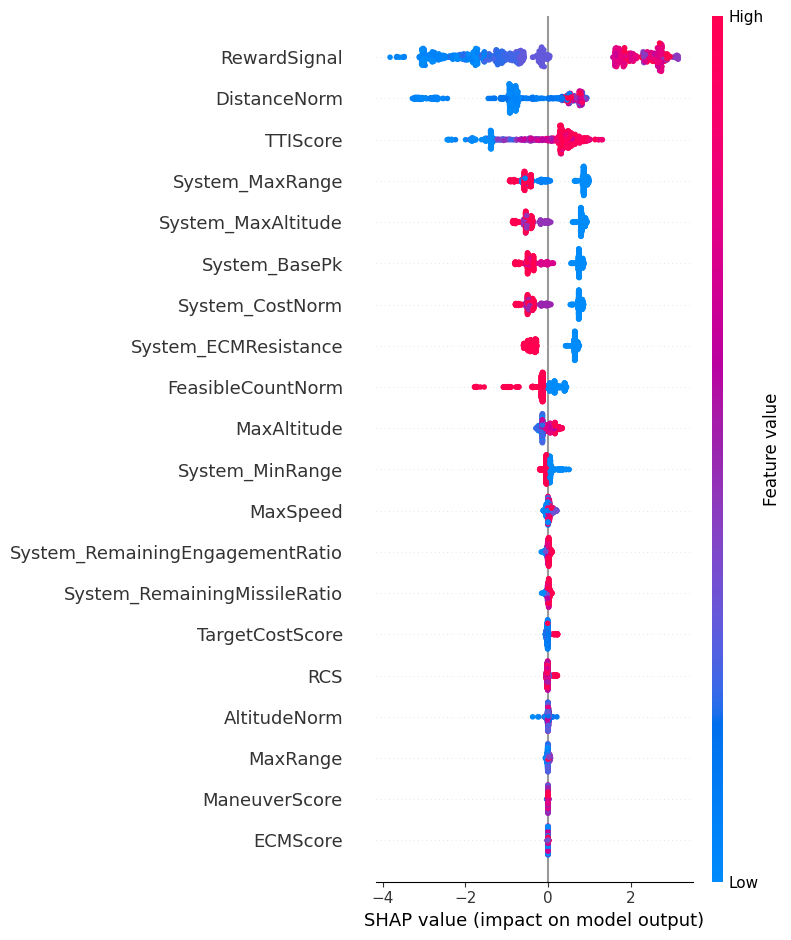


=== WATERFALL İÇİN SEÇİLEN ÖRNEK ===
ScenarioIdx             14
StepNo                   1
TargetName      B-2 Spirit
ChosenSystem       HİSAR A
Name: 70, dtype: object

Özellik değerleri:
                                       70
MaxSpeed                         0.329433
MaxRange                         0.788321
MaxAltitude                      0.733333
ManeuverScore                    0.250000
ECMScore                         0.750000
RCS                              1.000000
RewardSignal                     0.527206
TargetCostScore                  1.000000
DistanceNorm                     0.072867
AltitudeNorm                     0.026787
TTIScore                         1.000000
IFFNorm                          1.000000
FeasibleCountNorm                0.666667
System_MinRange                  0.020000
System_MaxRange                  0.100000
System_MaxAltitude               0.300000
System_RemainingEngagementRatio  1.000000
System_RemainingMissileRatio     1.000000
System_CostN

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


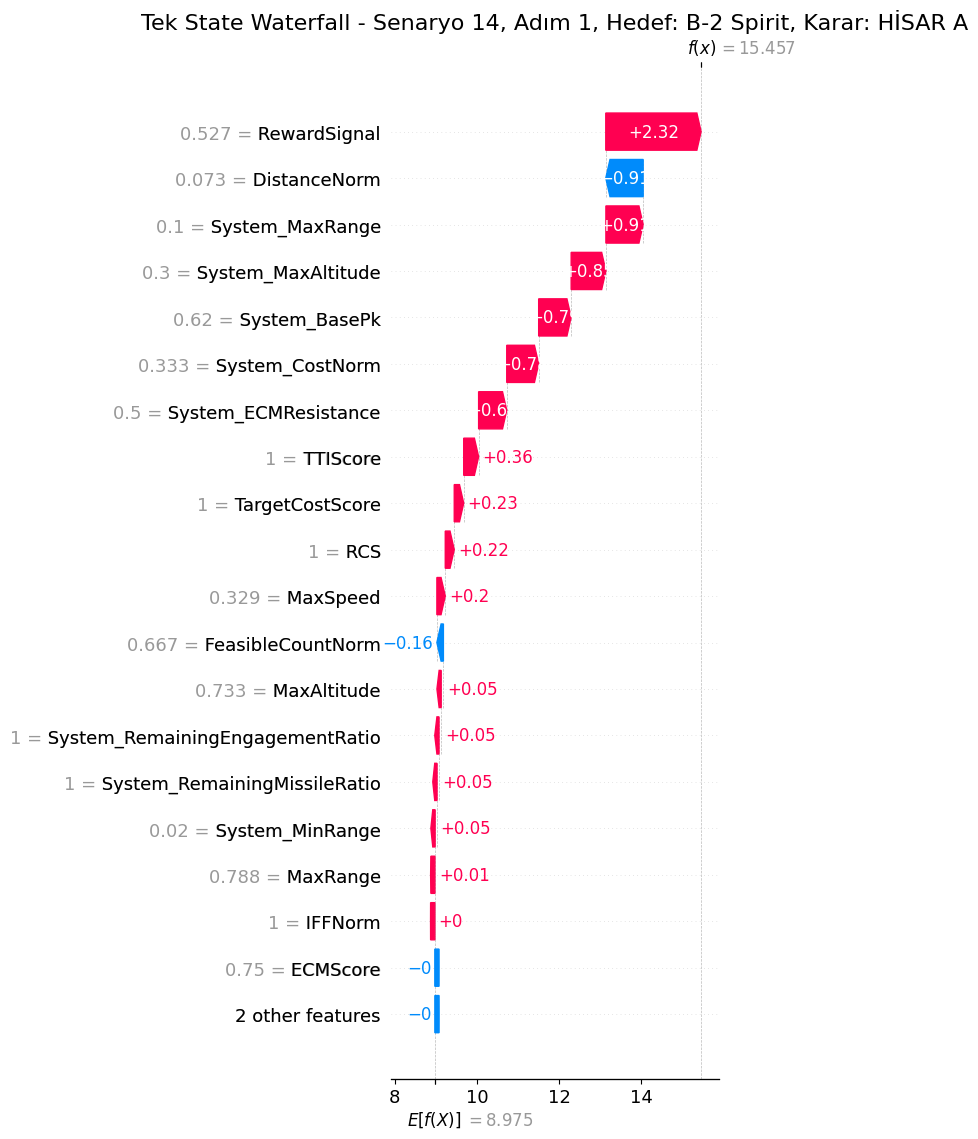


=== WATERFALL LOKAL SHAP TABLOSU ===
                            Feature  FeatureValue  SHAPValue   AbsSHAP
0                      RewardSignal      0.527206   2.320756  2.320756
1                      DistanceNorm      0.072867  -0.910243  0.910243
2                   System_MaxRange      0.100000   0.907349  0.907349
3                System_MaxAltitude      0.300000   0.845805  0.845805
4                     System_BasePk      0.620000   0.791052  0.791052
5                   System_CostNorm      0.333333   0.777463  0.777463
6              System_ECMResistance      0.500000   0.684698  0.684698
7                          TTIScore      1.000000   0.363094  0.363094
8                   TargetCostScore      1.000000   0.230559  0.230559
9                               RCS      1.000000   0.218563  0.218563
10                         MaxSpeed      0.329433   0.204011  0.204011
11                FeasibleCountNorm      0.666667  -0.158377  0.158377
12                      MaxAltitude    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [52]:
import os
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# =========================================================
# SHAP ANALİZİ İÇİN PLATFORM VERİSİ HAZIRLAMA
# =========================================================

required_platform_cols_df_rl = {
    "Name",
    "RewardSignal",
    "ECMScore",
    "MaxRange",
    "MaxAltitude",
    "ManeuverScore",
    "RCS",
    "TargetCostScore"
}

required_platform_cols_df_step2 = {
    "Name",
    "MaxSpeed"
}

if not required_platform_cols_df_rl.issubset(df_rl.columns):
    missing_cols = required_platform_cols_df_rl - set(df_rl.columns)
    raise ValueError(
        f"df_rl içinde SHAP için eksik sütunlar var: {missing_cols}. "
        f"Bu analiz için df_rl içinde {required_platform_cols_df_rl} olmalıdır."
    )

if not required_platform_cols_df_step2.issubset(df_step2.columns):
    missing_cols = required_platform_cols_df_step2 - set(df_step2.columns)
    raise ValueError(
        f"df_step2 içinde SHAP için eksik sütunlar var: {missing_cols}. "
        f"Bu analiz için df_step2 içinde {required_platform_cols_df_step2} olmalıdır."
    )

df_platform_shap = df_rl[
    [
        "Name",
        "RewardSignal",
        "ECMScore",
        "MaxRange",
        "MaxAltitude",
        "ManeuverScore",
        "RCS",
        "TargetCostScore"
    ]
].copy()

df_platform_speed = df_step2[
    [
        "Name",
        "MaxSpeed"
    ]
].copy()

df_platform_shap = df_platform_shap.merge(
    df_platform_speed,
    on="Name",
    how="left"
)

if df_platform_shap["MaxSpeed"].isna().any():
    missing_names = df_platform_shap[
        df_platform_shap["MaxSpeed"].isna()
    ]["Name"].tolist()

    raise ValueError(
        f"Şu hedefler için MaxSpeed bulunamadı: {missing_names}"
    )


# =========================================================
# NORMALİZASYON
# =========================================================

def minmax_normalize(series):
    smin = float(series.min())
    smax = float(series.max())

    if smax == smin:
        return pd.Series(
            np.ones(len(series)),
            index=series.index
        )

    return (series - smin) / (smax - smin)


df_platform_shap["MaxSpeedNorm"] = minmax_normalize(
    df_platform_shap["MaxSpeed"]
)

df_platform_shap["MaxRangeNorm"] = minmax_normalize(
    df_platform_shap["MaxRange"]
)

df_platform_shap["MaxAltitudeNorm"] = minmax_normalize(
    df_platform_shap["MaxAltitude"]
)

df_platform_shap["ManeuverScoreNorm"] = minmax_normalize(
    df_platform_shap["ManeuverScore"]
)

df_platform_shap["RCSNorm"] = minmax_normalize(
    df_platform_shap["RCS"]
)


# =========================================================
# SHAP ÖZELLİK SATIRI OLUŞTURMA
# =========================================================

def build_shap_feature_row(raw_env, target_idx, chosen_system_idx, df_platform_info):
    tgt = raw_env.df_targets.iloc[target_idx]
    tgt_name = tgt["Name"]

    platform_row = df_platform_info[
        df_platform_info["Name"] == tgt_name
    ]

    if len(platform_row) == 0:
        raise ValueError(
            f"{tgt_name} için platform SHAP bilgisi bulunamadı."
        )

    platform_row = platform_row.iloc[0]
    system = raw_env.systems[chosen_system_idx]

    remaining_eng_ratio = (
        raw_env.remaining_engagements[chosen_system_idx]
        / system["max_engagements"]
    )

    remaining_miss_ratio = (
        raw_env.remaining_missiles[chosen_system_idx]
        / system["max_missiles"]
    )

    feasible_count = raw_env._count_feasible_systems_for_target(
        target_idx
    )

    row = {
        # --- Platform teknik parametreleri ---
        "MaxSpeed": float(platform_row["MaxSpeedNorm"]),
        "MaxRange": float(platform_row["MaxRangeNorm"]),
        "MaxAltitude": float(platform_row["MaxAltitudeNorm"]),
        "ManeuverScore": float(platform_row["ManeuverScoreNorm"]),
        "ECMScore": float(np.clip(platform_row["ECMScore"], 0.0, 1.0)),
        "RCS": float(np.clip(platform_row["RCSNorm"], 0.0, 1.0)),

        # --- Hedef öncelik ve değer parametreleri ---
        "RewardSignal": float(
            np.clip(platform_row["RewardSignal"], 0.0, 1.0)
        ),
        "TargetCostScore": float(
            np.clip(platform_row["TargetCostScore"], 0.0, 1.0)
        ),

        # --- Hedefin anlık operasyonel durumu ---
        "DistanceNorm": float(
            np.clip(tgt["Distance_km"] / 150.0, 0.0, 1.0)
        ),
        "AltitudeNorm": float(
            np.clip(tgt["Altitude_m"] / 20000.0, 0.0, 1.0)
        ),
        "TTIScore": float(
            np.clip(tgt["TTI_score"], 0.0, 1.0)
        ),
        "IFFNorm": float(
            np.clip(tgt["IFF"] / 2.0, 0.0, 1.0)
        ),
        "FeasibleCountNorm": float(
            np.clip(feasible_count / raw_env.num_systems, 0.0, 1.0)
        ),

        # --- Seçilen hava savunma sistemine ait parametreler ---
        "System_MinRange": float(
            np.clip(system["min_range"] / 150.0, 0.0, 1.0)
        ),
        "System_MaxRange": float(
            np.clip(system["max_range"] / 150.0, 0.0, 1.0)
        ),
        "System_MaxAltitude": float(
            np.clip(system["max_altitude"] / 20000.0, 0.0, 1.0)
        ),
        "System_RemainingEngagementRatio": float(
            np.clip(remaining_eng_ratio, 0.0, 1.0)
        ),
        "System_RemainingMissileRatio": float(
            np.clip(remaining_miss_ratio, 0.0, 1.0)
        ),
        "System_CostNorm": float(
            np.clip(system["cost"] / 3.0, 0.0, 1.0)
        ),
        "System_BasePk": float(
            np.clip(system["base_pk"], 0.0, 1.0)
        ),
        "System_ECMResistance": float(
            np.clip(system["ecm_resistance"], 0.0, 1.0)
        )
    }

    return row


# =========================================================
# SHAP EĞİTİM VERİSİ TOPLAMA
# =========================================================

def collect_shap_training_data(model, scenarios, df_platform_info, max_samples=800):
    X_rows = []
    y_rows = []
    meta_rows = []

    sample_count = 0

    for sc_idx, scenario in enumerate(scenarios):
        raw_env = MultiTargetTEWAEnv(
            [scenario],
            max_targets=MAX_TARGETS
        )

        env = ActionMasker(
            raw_env,
            mask_fn
        )

        obs, info = env.reset()
        done = False
        step_no = 0

        while not done:
            current_masks = get_action_masks(env)

            action, _ = model.predict(
                obs,
                deterministic=True,
                action_masks=current_masks
            )

            target_idx, local_action = raw_env._decode_action(
                int(action)
            )

            if (
                local_action != raw_env.num_systems
                and target_idx < raw_env.num_targets
            ):
                feature_row = build_shap_feature_row(
                    raw_env=raw_env,
                    target_idx=target_idx,
                    chosen_system_idx=local_action,
                    df_platform_info=df_platform_info
                )

                reward_value = raw_env._compute_reward(
                    target_idx,
                    local_action
                )

                X_rows.append(feature_row)
                y_rows.append(float(reward_value))

                meta_rows.append({
                    "ScenarioIdx": sc_idx + 1,
                    "StepNo": step_no + 1,
                    "TargetName": raw_env.df_targets.iloc[target_idx]["Name"],
                    "ChosenSystem": raw_env.systems[local_action]["name"]
                })

                sample_count += 1

                if sample_count >= max_samples:
                    return (
                        pd.DataFrame(X_rows),
                        np.array(y_rows),
                        pd.DataFrame(meta_rows)
                    )

            obs, reward, done, truncated, step_info = env.step(action)
            step_no += 1

    return (
        pd.DataFrame(X_rows),
        np.array(y_rows),
        pd.DataFrame(meta_rows)
    )


# =========================================================
# SHAP VERİSİNİ OLUŞTUR
# =========================================================

X_shap, y_shap, df_shap_meta = collect_shap_training_data(
    model=model,
    scenarios=eval_test_scenarios if RUN_FULL_EVAL else test_scenarios,
    df_platform_info=df_platform_shap,
    max_samples=800
)

print("\n=== SHAP SURROGATE VERİ BOYUTLARI ===")
print("X_shap shape:", X_shap.shape)
print("y_shap shape:", y_shap.shape)

if len(X_shap) < 30:
    raise ValueError(
        "SHAP için yeterli sayıda angajman örneği toplanamadı. "
        "max_samples değerini artırmayı deneyin."
    )


# =========================================================
# RANDOM FOREST SURROGATE MODEL
# =========================================================

surrogate_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

surrogate_model.fit(
    X_shap,
    y_shap
)

y_pred = surrogate_model.predict(
    X_shap
)

print("\n=== SURROGATE MODEL PERFORMANSI ===")
print("R2  :", round(r2_score(y_shap, y_pred), 4))
print("MAE :", round(mean_absolute_error(y_shap, y_pred), 4))


# =========================================================
# GLOBAL SHAP ANALİZİ
# =========================================================

explainer = shap.TreeExplainer(
    surrogate_model
)

shap_values_all = explainer(
    X_shap
)

global_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "MeanAbsSHAP": np.abs(shap_values_all.values).mean(axis=0)
}).sort_values(
    by="MeanAbsSHAP",
    ascending=False
).reset_index(drop=True)

print("\n=== GLOBAL SHAP İLK 20 ===")
print(global_importance.head(20))

global_importance.to_excel(
    os.path.join(OUTPUT_DIR, "detailed_shap_global_importance.xlsx"),
    index=False
)

plt.figure(figsize=(10, 7), dpi=300)

plt.barh(
    global_importance["Feature"].head(20)[::-1],
    global_importance["MeanAbsSHAP"].head(20)[::-1],
    edgecolor="black"
)

plt.xlabel("Mean |SHAP|")
plt.ylabel("Özellik")
plt.title("Detaylı Global SHAP Özellik Önemi")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "detailed_shap_global_bar.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


plt.figure()

shap.summary_plot(
    shap_values_all.values,
    X_shap,
    feature_names=X_shap.columns.tolist(),
    show=False,
    max_display=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "detailed_shap_summary_plot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# =========================================================
# WATERFALL SHAP ANALİZİ
# =========================================================

example_idx = int(np.argmax(y_shap))

example_meta = df_shap_meta.iloc[example_idx]
example_x = X_shap.iloc[[example_idx]]
example_explanation = explainer(example_x)

print("\n=== WATERFALL İÇİN SEÇİLEN ÖRNEK ===")
print(example_meta)

print("\nÖzellik değerleri:")
print(example_x.T)

plt.figure()

shap.plots.waterfall(
    example_explanation[0],
    max_display=20,
    show=False
)

plt.title(
    f"Tek State Waterfall - Senaryo {example_meta['ScenarioIdx']}, "
    f"Adım {example_meta['StepNo']}, "
    f"Hedef: {example_meta['TargetName']}, "
    f"Karar: {example_meta['ChosenSystem']}",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "detailed_shap_waterfall.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# =========================================================
# LOKAL SHAP TABLOSU
# =========================================================

df_local_shap = pd.DataFrame({
    "Feature": example_x.columns,
    "FeatureValue": example_x.iloc[0].values,
    "SHAPValue": example_explanation.values[0],
    "AbsSHAP": np.abs(example_explanation.values[0])
}).sort_values(
    by="AbsSHAP",
    ascending=False
).reset_index(drop=True)

print("\n=== WATERFALL LOKAL SHAP TABLOSU ===")
print(df_local_shap.head(20))

df_local_shap.to_excel(
    os.path.join(OUTPUT_DIR, "detailed_shap_local_values.xlsx"),
    index=False
)


# =========================================================
# SHAP RAPOR DOSYASI
# =========================================================

with open(
    os.path.join(OUTPUT_DIR, "detailed_shap_report.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write("DETAILED SHAP REPORT\n")
    f.write("=" * 90 + "\n\n")

    f.write(f"Toplam açıklama örneği      : {len(X_shap)}\n")
    f.write(f"Surrogate model R2          : {r2_score(y_shap, y_pred):.4f}\n")
    f.write(f"Surrogate model MAE         : {mean_absolute_error(y_shap, y_pred):.4f}\n\n")

    f.write("GLOBAL SHAP İLK 20\n")
    f.write("-" * 90 + "\n")
    f.write(global_importance.head(20).to_string(index=False))
    f.write("\n\n")

    f.write("WATERFALL İÇİN SEÇİLEN ÖRNEK\n")
    f.write("-" * 90 + "\n")
    f.write(example_meta.to_string())
    f.write("\n\n")

    f.write("LOKAL SHAP İLK 20\n")
    f.write("-" * 90 + "\n")
    f.write(df_local_shap.head(20).to_string(index=False))
    f.write("\n")


print("\nDetaylı SHAP analizi tamamlandı.")
print("Kaydedilen dosyalar:")

for file_name in [
    "detailed_shap_global_importance.xlsx",
    "detailed_shap_global_bar.png",
    "detailed_shap_summary_plot.png",
    "detailed_shap_waterfall.png",
    "detailed_shap_local_values.xlsx",
    "detailed_shap_report.txt"
]:
    full_path = os.path.join(OUTPUT_DIR, file_name)

    if os.path.exists(full_path):
        print("-", full_path)
